<a href="https://colab.research.google.com/github/oleksiikartashovde-glitch/Zero-point/blob/main/all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# =====================================================================
# ШАГ 0: СИСТЕМНАЯ УСТАНОВКА БИБЛИОТЕКИ В КОЛАБ
# =====================================================================

import cv2
import numpy as np
import pandas as pd

# =====================================================================
# ШАГ 1: ЗАГРУЗКА ИЗОБРАЖЕНИЙ И БИНАРИЗАЦИЯ
# =====================================================================
# ВАЖНО: На панели файлов Colab должны быть файлы zero.png и symbol.png
img_zero = cv2.imread('zero.png', 0)
img_symbol = cv2.imread('symbol.png', 0)

if img_zero is None or img_symbol is None:
    raise FileNotFoundError("Ошибка: Проверьте наличие файлов 'zero.png' и 'symbol.png' в панели Colab!")

# Переводим в бинарные маски (объект — белый, фон — черный)
_, bin_zero = cv2.threshold(img_zero, 127, 255, cv2.THRESH_BINARY)
_, bin_symbol = cv2.threshold(img_symbol, 127, 255, cv2.THRESH_BINARY)

# =====================================================================
# ШАГ 2: ИЗВЛЕЧЕНИЕ ПЛОСКИХ МОМЕНТОВ ХУ И ИХ ЛОГАРИФМИРОВАНИЕ
# =====================================================================
hu_z = cv2.HuMoments(cv2.moments(bin_zero)).flatten()
hu_x = cv2.HuMoments(cv2.moments(bin_symbol)).flatten()

hu_z_log = -np.sign(hu_z) * np.log10(np.abs(hu_z) + 1e-15)
hu_x_log = -np.sign(hu_x) * np.log10(np.abs(hu_x) + 1e-15)

# =====================================================================
# ШАГ 3: СБОРКА ЕДИНОГО ВЕКТОРНОГО ПАСПОРТА ФОРМЫ (7 ПАРАМЕТРОВ)
# =====================================================================
vector_z = hu_z_log
vector_x = hu_x_log

labels = [f'h{i+1}' for i in range(7)]

descriptions = [
    "h1: Компактность / Общая плотность распределения массы силуэта на плоскости",
    "h2: Степень вытянутости (отношение длинной оси объекта к короткой)",
    "h3: Асимметрия изгибов контура (направленный пространственный эксцентриситет)",
    "h4: Степень ортогональности (наличие прямых углов и Т-образных стыков/перекрестий)",
    "h5: Пропорциональный баланс диагональных элементов (динамика/разлет формы)",
    "h6: Симметрия ориентации (характер закрученности хвостов и дериватов силуэта)",
    "h7: Косая симметрия знака (фундаментальный маркер зеркального отражения)"
]

df_params = pd.DataFrame({
    'Метрика': labels,
    'Геометрическое свойство (Композиционный Гештальт)': descriptions,
    'Точка Ноль (Z)': np.round(vector_z, 5),
    'Символ (X)': np.round(vector_x, 5),
    'Линейная разность (Z-X)': np.round(vector_z - vector_x, 5)
})

print("=" * 125)
print(" 1. СИНТЕЗИРОВАННЫЙ ПАСПОРТ ГЕОМЕТРИЧЕСКИХ ИНВАРИАНТОВ ФОРМЫ (ТОЧКА НОЛЬ vs СИМВОЛ):")
print("=" * 125)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_params.to_string(index=False))
print("-" * 125 + "\n")

# =====================================================================
# ШАГ 4: ПОШАГОВАЯ ДЕМОНСТРАЦИЯ МАТЕМАТИЧЕСКОГО РАСЧЕТА ДИСТАНЦИИ
# =====================================================================
print(" 2. ПОШАГОВЫЙ МАТЕМАТИЧЕСКИЙ РАСЧЕТ В РАСШИРЕННОМ ПРОСТРАНСТВЕ ПРИЗНАКОВ:")
print("-" * 125)

sum_squared_zero = np.sum(vector_z ** 2)
d_max = np.sqrt(sum_squared_zero)

print(f" а) Вычисляем модуль вектора Точки Ноль (Ориентир d_max для 100% шкалы):")
print(f"    • Сумма квадратов всех {len(labels)} параметров Точки Ноль = {sum_squared_zero:.5f}")
print(f"    • Длина опорного вектора Точки Ноль (d_max)      = {d_max:.5f}\n")

diff = vector_z - vector_x
sum_squared_diff = np.sum(diff ** 2)
d_symbol = np.sqrt(sum_squared_diff)

print(f" б) Вычисляем Евклидову дистанцию между вектором Символа и Точкой Ноль (d_symbol):")
print(f"    • Сумма квадратов линейных разностей параметров (Hu) = {sum_squared_diff:.5f}")
print(f"    • Чистая Евклидова дистанция от Точки Ноль до Символа            = {d_symbol:.5f}\n")

# =====================================================================
# ШАГ 5: ИТОГОВЫЙ СЕМАНТИЧЕСКИЙ ВЕРДИКТ
# =====================================================================
raw_percentage = (d_symbol / d_max) * 100
distance_percentage = min(raw_percentage, 100.0)
match_percentage = 100.0 - distance_percentage

print("=" * 125)
print(" 3. ФИНАЛЬНЫЙ МЕТРИЧЕСКИЙ ОТЧЕТ:")
print("=" * 125)
print(f" • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): {distance_percentage:.2f}%")
print(f" • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    {match_percentage:.2f}%")
print("-" * 125)

if distance_percentage == 0:
    print(" 🟢 Итог: Полное тождество Символа и Точки Ноль.")
elif distance_percentage < 20:
    print(f" ✅ Малая дистанция ({distance_percentage:.2f}%): Структурный изоморфизм подтвержден. Символ находится в зоне когнитивного притяжения Точки Ноль.")
elif distance_percentage < 60:
    print(f" 🟠 Средняя дистанция ({distance_percentage:.2f}%): Объекты имеют общее частотное ядро, но топологические детали разведены.")
else:
    print(" 🔴 Максимальное удаление: Символ ортогонален Точке Ноль. Геометрическое родство отсутствует.")
print("=" * 125)

 1. СИНТЕЗИРОВАННЫЙ ПАСПОРТ ГЕОМЕТРИЧЕСКИХ ИНВАРИАНТОВ ФОРМЫ (ТОЧКА НОЛЬ vs СИМВОЛ):
Метрика                                  Геометрическое свойство (Композиционный Гештальт)  Точка Ноль (Z)  Символ (X)  Линейная разность (Z-X)
     h1        h1: Компактность / Общая плотность распределения массы силуэта на плоскости         2.78175     2.58598                  0.19577
     h2                 h2: Степень вытянутости (отношение длинной оси объекта к короткой)         5.77069     5.27437                  0.49632
     h3      h3: Асимметрия изгибов контура (направленный пространственный эксцентриситет)         8.83903     7.90164                  0.93738
     h4 h4: Степень ортогональности (наличие прямых углов и Т-образных стыков/перекрестий)         9.09502     8.06166                  1.03336
     h5         h5: Пропорциональный баланс диагональных элементов (динамика/разлет формы)        14.99963    14.96261                  0.03702
     h6      h6: Симметрия ориентации (характер зак

In [7]:
# Install mahotas library
!pip install mahotas

## Zernike Moments Calculation (Отдельный Блок)

In [15]:
import mahotas as mh
import pandas as pd
import numpy as np

zernike_radius = 4 # Use the original fixed radius
# The 'order' parameter defaults to 8 in mahotas.features.zernike_moments when not specified,
# which yields 25 moments for real images (m >= 0, (n-m) even).

print(f"Calculating Zernike Moments for radius: {zernike_radius} (default order=8, yielding 25 moments)")
print("=" * 100)

z_z = mh.features.zernike_moments(bin_zero, radius=zernike_radius)
z_x = mh.features.zernike_moments(bin_symbol, radius=zernike_radius)

num_moments = len(z_z) # This will be 25

zernike_labels = [f'z{i+1}' for i in range(num_moments)]

# Generate descriptions based on (n,m) pairs for order 8 (25 moments)
# The order of moments returned by mahotas is typically (n,m) where m >= 0 and (n-m) is even.
# The sequence is: (0,0), (1,1), (2,0), (2,2), (3,1), (3,3), (4,0), (4,2), (4,4),
# (5,1), (5,3), (5,5), (6,0), (6,2), (6,4), (6,6), (7,1), (7,3), (7,5), (7,7),
# (8,0), (8,2), (8,4), (8,6), (8,8)
zernike_descriptions = [
    "z1 (n=0, m=0): Общая масса внутри единичного круга",
    "z2 (n=1, m=1): Линейный радиальный сдвиг массы от центра масс",
    "z3 (n=2, m=0): Радиальная концентрация (Ядро против Периферии)",
    "z4 (n=2, m=2): Квадрупольная полярная асимметрия (2 луча)",
    "z5 (n=3, m=1): Сложный радиальный изгиб внутренних слоев",
    "z6 (n=3, m=3): Треугольная полярная гармоника (3 луча)",
    "z7 (n=4, m=0): Четвертая радиальная мода, нулевая угловая частота (четырехугольная симметрия)",
    "z8 (n=4, m=2): Четвертая радиальная мода, вторая угловая частота",
    "z9 (n=4, m=4): Четвертая радиальная мода, четвертая угловая частота",
    "z10 (n=5, m=1): Пятая радиальная мода, первая угловая частота",
    "z11 (n=5, m=3): Пятая радиальная мода, третья угловая частота",
    "z12 (n=5, m=5): Пятая радиальная мода, пятая угловая частота",
    "z13 (n=6, m=0): Шестая радиальная мода, нулевая угловая частота (шестиугольная симметрия)",
    "z14 (n=6, m=2): Шестая радиальная мода, вторая угловая частота",
    "z15 (n=6, m=4): Шестая радиальная мода, четвертая угловая частота",
    "z16 (n=6, m=6): Шестая радиальная мода, шестая угловая частота",
    "z17 (n=7, m=1): Седьмая радиальная мода, первая угловая частота",
    "z18 (n=7, m=3): Седьмая радиальная мода, третья угловая частота",
    "z19 (n=7, m=5): Седьмая радиальная мода, пятая угловая частота",
    "z20 (n=7, m=7): Седьмая радиальная мода, седьмая угловая частота",
    "z21 (n=8, m=0): Восьмая радиальная мода, нулевая угловая частота (восьмиугольная симметрия)",
    "z22 (n=8, m=2): Восьмая радиальная мода, вторая угловая частота",
    "z23 (n=8, m=4): Восьмая радиальная мода, четвертая угловая частота",
    "z24 (n=8, m=6): Восьмая радиальная мода, шестая угловая частота",
    "z25 (n=8, m=8): Восьмая радиальная мода, восьмая угловая частота"
]

# Ensure descriptions match the number of moments (should be 25)
current_descriptions = zernike_descriptions[:num_moments]
if len(current_descriptions) < num_moments:
    for i in range(len(current_descriptions), num_moments):
        current_descriptions.append(f"z{i+1}: Дополнительный момент Цернике (n=?, m=?)")

df_zernike = pd.DataFrame({
    'Метрика': zernike_labels,
    'Геометрическое свойство': current_descriptions,
    'Точка Ноль (Z)': np.round(z_z, 5),
    'Символ (X)': np.round(z_x, 5),
    'Линейная разность (Z-X)': np.round(z_z - z_x, 5)
})

print("РАДИАЛЬНЫЕ МОМЕНТЫ ЦЕРНИКЕ (ПОЛЯРНЫЙ БАЗИС):")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_zernike.to_string(index=False))
print("-" * 100)

# =====================================================================
# ПОШАГОВАЯ ДЕМОНСТРАЦИЯ МАТЕМАТИЧЕСКОГО РАСЧЕТА ДИСТАНЦИИ ДЛЯ ZERNIKE
# =====================================================================
print("\n2. ПОШАГОВЫЙ МАТЕМАТИЧЕСКИЙ РАСЧЕТ В РАСШИРЕННОМ ПРОСТРАНСТВЕ ПРИЗНАКОВ (ZERNIKE):")
print("-" * 125)

sum_squared_zero_zernike = np.sum(z_z ** 2)
d_max_zernike = np.sqrt(sum_squared_zero_zernike)

print(f" а) Вычисляем модуль вектора Точки Ноль (Ориентир d_max для 100% шкалы) для Цернике:")
print(f"    • Сумма квадратов всех {num_moments} параметров Точки Ноль = {sum_squared_zero_zernike:.5f}")
print(f"    • Длина опорного вектора Точки Ноль (d_max)      = {d_max_zernike:.5f}\n")

diff_zernike = z_z - z_x
sum_squared_diff_zernike = np.sum(diff_zernike ** 2)
d_symbol_zernike = np.sqrt(sum_squared_diff_zernike)

print(f" б) Вычисляем Евклидову дистанцию между вектором Символа и Точкой Ноль (d_symbol) для Цернике:")
print(f"    • Сумма квадратов линейных разностей параметров (Zernike) = {sum_squared_diff_zernike:.5f}")
print(f"    • Чистая Евклидова дистанция от Точки Ноль до Символа            = {d_symbol_zernike:.5f}\n")

# =====================================================================
# ИТОГОВЫЙ СЕМАНТИЧЕСКИЙ ВЕРДИКТ ДЛЯ ZERNIKE
# =====================================================================
raw_percentage_zernike = (d_symbol_zernike / d_max_zernike) * 100
distance_percentage_zernike = min(raw_percentage_zernike, 100.0)
match_percentage_zernike = 100.0 - distance_percentage_zernike

print("=" * 125)
print("3. ФИНАЛЬНЫЙ МЕТРИЧЕСКИЙ ОТЧЕТ (ZERNIKE):")
print("=" * 125)
print(f" • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): {distance_percentage_zernike:.2f}%")
print(f" • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    {match_percentage_zernike:.2f}%")
print("-" * 125)

if distance_percentage_zernike == 0:
    print(" 🟢 Итог: Полное тождество Символа и Точки Ноль (Zernike).")
elif distance_percentage_zernike < 20:
    print(f" ✅ Малая дистанция ({distance_percentage_zernike:.2f}%): Структурный изоморфизм подтвержден. Символ находится в зоне когнитивного притяжения Точки Ноль (Zernike).")
elif distance_percentage_zernike < 60:
    print(f" 🟠 Средняя дистанция ({distance_percentage_zernike:.2f}%): Объекты имеют общее частотное ядро, но топологические детали разведены (Zernike).")
else:
    print(" 🔴 Максимальное удаление: Символ ортогонален Точке Ноль. Геометрическое родство отсутствует (Zernike).")
print("=" * 125)

Calculating Zernike Moments for radius: 4 (default order=8, yielding 25 moments)
РАДИАЛЬНЫЕ МОМЕНТЫ ЦЕРНИКЕ (ПОЛЯРНЫЙ БАЗИС):
Метрика                                                                       Геометрическое свойство  Точка Ноль (Z)  Символ (X)  Линейная разность (Z-X)
     z1                                            z1 (n=0, m=0): Общая масса внутри единичного круга         0.31831     0.31831                 -0.00000
     z2                                 z2 (n=1, m=1): Линейный радиальный сдвиг массы от центра масс         0.02069     0.01432                  0.00637
     z3                                z3 (n=2, m=0): Радиальная концентрация (Ядро против Периферии)         0.00152     0.01409                 -0.01258
     z4                                     z4 (n=2, m=2): Квадрупольная полярная асимметрия (2 луча)         0.03469     0.02632                  0.00838
     z5                                      z5 (n=3, m=1): Сложный радиальный изгиб внутренних сло

## Расчет Расстояния Хаусдорфа (Отдельный Блок)

In [17]:
from scipy.spatial.distance import directed_hausdorff

# Преобразуем бинарные изображения в массивы координат точек контура
# cv2.findContours возвращает list of arrays, каждый массив - это точки одного контура.
# Для Hausdorff distance нам нужен один массив точек.

# Для bin_zero
contours_zero, _ = cv2.findContours(bin_zero, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
if not contours_zero:
    print("Ошибка: Контуры для 'zero.png' не найдены.")
    points_zero = np.array([])
else:
    # Объединяем все контуры в один массив точек
    points_zero = np.vstack(contours_zero).squeeze()

# Для bin_symbol
contours_symbol, _ = cv2.findContours(bin_symbol, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
if not contours_symbol:
    print("Ошибка: Контуры для 'symbol.png' не найдены.")
    points_symbol = np.array([])
else:
    # Объединяем все контуры в один массив точек
    points_symbol = np.vstack(contours_symbol).squeeze()

# Проверяем, что есть точки для обоих изображений перед расчетом
if points_zero.shape[0] > 0 and points_symbol.shape[0] > 0:
    # Расчет направленного расстояния Хаусдорфа
    # d(u, v) - максимальное расстояние от точки в u до ближайшей точки в v
    hausdorff_dist_zero_to_symbol = directed_hausdorff(points_zero, points_symbol)[0]
    hausdorff_dist_symbol_to_zero = directed_hausdorff(points_symbol, points_zero)[0]

    # Расстояние Хаусдорфа - максимум из двух направленных расстояний
    symmetric_hausdorff_distance = max(hausdorff_dist_zero_to_symbol, hausdorff_dist_symbol_to_zero)

    print("=" * 100)
    print("РАСЧЕТ РАССТОЯНИЯ ХАУСДОРФА:")
    print("=" * 100)
    print(f"Направленное расстояние Хаусдорфа от Zero к Symbol: {hausdorff_dist_zero_to_symbol:.3f}")
    print(f"Направленное расстояние Хаусдорфа от Symbol к Zero: {hausdorff_dist_symbol_to_zero:.3f}")
    print(f"Симметричное расстояние Хаусдорфа (максимальное расхождение контуров): {symmetric_hausdorff_distance:.3f}")
    print("-" * 100)

    # =====================================================================
    # ПОШАГОВАЯ ДЕМОНСТРАЦИЯ МАТЕМАТИЧЕСКОГО РАСЧЕТА ДИСТАНЦИИ ДЛЯ ХАУСДОРФА
    # =====================================================================
    print("\n2. ПОШАГОВЫЙ МАТЕМАТИЧЕСКИЙ РАСЧЕТ В РАСШИРЕННОМ ПРОСТРАНСТВЕ ПРИЗНАКОВ (ХАУСДОРФ):")
    print("-" * 125)

    # Determine the maximum possible Hausdorff distance for scaling
    # Using the diagonal of the image as the maximum possible distance
    img_height, img_width = bin_zero.shape # Assuming images are of the same size, use bin_zero dimensions
    d_max_hausdorff = np.sqrt(img_height**2 + img_width**2)

    print(f" а) Вычисляем максимальную возможную дистанцию (Ориентир d_max для 100% шкалы):")
    print(f"    • Максимальная диагональ изображения (d_max)      = {d_max_hausdorff:.3f}\n")

    d_symbol_hausdorff = symmetric_hausdorff_distance

    print(f" б) Евклидова дистанция (симметричное расстояние Хаусдорфа):")
    print(f"    • Чистая Евклидова дистанция (Hausdorff)            = {d_symbol_hausdorff:.3f}\n")

    # =====================================================================
    # ИТОГОВЫЙ СЕМАНТИЧЕСКИЙ ВЕРДИКТ ДЛЯ ХАУСДОРФА
    # =====================================================================
    raw_percentage_hausdorff = (d_symbol_hausdorff / d_max_hausdorff) * 100
    distance_percentage_hausdorff = min(raw_percentage_hausdorff, 100.0)
    match_percentage_hausdorff = 100.0 - distance_percentage_hausdorff

    print("=" * 125)
    print("3. ФИНАЛЬНЫЙ МЕТРИЧЕСКИЙ ОТЧЕТ (ХАУСДОРФ):")
    print("=" * 125)
    print(f" • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): {distance_percentage_hausdorff:.2f}%")
    print(f" • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    {match_percentage_hausdorff:.2f}%")
    print("-" * 125)

    if distance_percentage_hausdorff == 0:
        print(" 🟢 Итог: Полное тождество Символа и Точки Ноль (Hausdorff).")
    elif distance_percentage_hausdorff < 20:
        print(f" ✅ Малая дистанция ({distance_percentage_hausdorff:.2f}%): Структурный изоморфизм подтвержден. Символ находится в зоне когнитивного притяжения Точки Ноль (Hausdorff).")
    elif distance_percentage_hausdorff < 60:
        print(f" 🟠 Средняя дистанция ({distance_percentage_hausdorff:.2f}%): Объекты имеют общее частотное ядро, но топологические детали разведены (Hausdorff).")
    else:
        print(" 🔴 Максимальное удаление: Символ ортогонален Точке Ноль. Геометрическое родство отсутствует (Hausdorff).")
    print("=" * 125)
else:
    print("Недостаточно данных для расчета расстояния Хаусдорфа: один или оба контура пусты.")

РАСЧЕТ РАССТОЯНИЯ ХАУСДОРФА:
Направленное расстояние Хаусдорфа от Zero к Symbol: 427.163
Направленное расстояние Хаусдорфа от Symbol к Zero: 212.850
Симметричное расстояние Хаусдорфа (максимальное расхождение контуров): 427.163
----------------------------------------------------------------------------------------------------

2. ПОШАГОВЫЙ МАТЕМАТИЧЕСКИЙ РАСЧЕТ В РАСШИРЕННОМ ПРОСТРАНСТВЕ ПРИЗНАКОВ (ХАУСДОРФ):
-----------------------------------------------------------------------------------------------------------------------------
 а) Вычисляем максимальную возможную дистанцию (Ориентир d_max для 100% шкалы):
    • Максимальная диагональ изображения (d_max)      = 3574.449

 б) Евклидова дистанция (симметричное расстояние Хаусдорфа):
    • Чистая Евклидова дистанция (Hausdorff)            = 427.163

3. ФИНАЛЬНЫЙ МЕТРИЧЕСКИЙ ОТЧЕТ (ХАУСДОРФ):
 • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): 11.95%
 • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    88.05%
----------------------------

## Расчет Пересечения Площадей (Overlap Calculation)

In [24]:
import cv2
import numpy as np

print("=" * 100)
print("РАСЧЕТ ПЕРЕСЕЧЕНИЯ ПЛОЩАДЕЙ:")
print("=" * 100)

# Calculate areas (number of white pixels)
area_zero = cv2.countNonZero(bin_zero)
area_symbol = cv2.countNonZero(bin_symbol)

# Calculate intersection and union masks
intersection_mask = cv2.bitwise_and(bin_zero, bin_symbol)
union_mask = cv2.bitwise_or(bin_zero, bin_symbol)

# Calculate areas of intersection and union
intersection_area = cv2.countNonZero(intersection_mask)
union_area = cv2.countNonZero(union_mask)

print(f"Площадь Zero (белые пиксели): {area_zero} пикселей")
print(f"Площадь Symbol (белые пиксели): {area_symbol} пикселей")
print(f"Площадь Пересечения (Intersection): {intersection_area} пикселей")
print(f"Площадь Объединения (Union): {union_area} пикселей\n")

# Calculate Jaccard Index (Intersection over Union, IoU)
jaccard_index = intersection_area / union_area if union_area > 0 else 0

# Calculate Dice Coefficient
dice_coefficient = (2 * intersection_area) / (area_zero + area_symbol) if (area_zero + area_symbol) > 0 else 0

print(f"Индекс Жаккара (Intersection over Union, IoU): {jaccard_index:.3f}")
print(f"Коэффициент Дайса (Dice Coefficient): {dice_coefficient:.3f}")
print("-" * 100)

# =====================================================================
# ПОШАГОВАЯ ДЕМОНСТРАЦИЯ МАТЕМАТИЧЕСКОГО РАСЧЕТА ДИСТАНЦИИ ДЛЯ ПЕРЕСЕЧЕНИЯ
# =====================================================================
print("\n2. ПОШАГОВЫЙ МАТЕМАТИЧЕСКИЙ РАСЧЕТ В РАСШИРЕННОМ ПРОСТРАНСТВЕ ПРИЗНАКОВ (ПЕРЕСЕЧЕНИЕ):")
print("-" * 125)

# d_max for overlap can be the area of the smaller object, representing 100% overlap if one is contained.
d_max_overlap = min(area_zero, area_symbol)

# Using the Jaccard Index as a base for similarity. Dissimilarity is 1 - Jaccard Index.
d_dissimilarity_overlap = 1 - jaccard_index

print(f" а) Вычисляем максимальную возможную площадь перекрытия (Ориентир d_max для 100% шкалы):")
print(f"    • Максимальная возможная площадь перекрытия (d_max) = {d_max_overlap} пикселей\n")

print(f" б) Евклидова дистанция (показатель диссонанса на основе Индекса Жаккара):")
print(f"    • Диссонанс (1 - IoU)                           = {d_dissimilarity_overlap:.3f}\n")

# =====================================================================
# ИТОГОВЫЙ СЕМАНТИЧЕСКИЙ ВЕРДИКТ ДЛЯ ПЕРЕСЕЧЕНИЯ
# =====================================================================
# The 'distance' here is actually the dissimilarity (1 - similarity).
# We normalize this dissimilarity to get a percentage.

distance_percentage_overlap = d_dissimilarity_overlap * 100
match_percentage_overlap = jaccard_index * 100

print("=" * 125)
print("3. ФИНАЛЬНЫЙ МЕТРИЧЕСКИЙ ОТЧЕТ (ПЕРЕСЕЧЕНИЕ):")
print("=" * 125)
print(f" • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): {distance_percentage_overlap:.2f}%")
print(f" • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    {match_percentage_overlap:.2f}%")
print("-" * 125)

if match_percentage_overlap == 100:
    print(" 🟢 Итог: Полное совпадение форм (Пересечение).")
elif match_percentage_overlap > 80:
    print(f" ✅ Высокое сходство ({match_percentage_overlap:.2f}%): Значительное перекрытие, формы очень похожи (Пересечение).")
elif match_percentage_overlap > 50:
    print(f" 🟠 Среднее сходство ({match_percentage_overlap:.2f}%): Умеренное перекрытие, формы имеют общие черты (Пересечение).")
else:
    print(f" 🔴 Низкое сходство ({match_percentage_overlap:.2f}%): Незначительное перекрытие, формы сильно различаются (Пересечение).")
print("=" * 125)

РАСЧЕТ ПЕРЕСЕЧЕНИЯ ПЛОЩАДЕЙ:
Площадь Zero (белые пиксели): 1117515 пикселей
Площадь Symbol (белые пиксели): 445722 пикселей
Площадь Пересечения (Intersection): 445661 пикселей
Площадь Объединения (Union): 1117576 пикселей

Индекс Жаккара (Intersection over Union, IoU): 0.399
Коэффициент Дайса (Dice Coefficient): 0.570
----------------------------------------------------------------------------------------------------

2. ПОШАГОВЫЙ МАТЕМАТИЧЕСКИЙ РАСЧЕТ В РАСШИРЕННОМ ПРОСТРАНСТВЕ ПРИЗНАКОВ (ПЕРЕСЕЧЕНИЕ):
-----------------------------------------------------------------------------------------------------------------------------
 а) Вычисляем максимальную возможную площадь перекрытия (Ориентир d_max для 100% шкалы):
    • Максимальная возможная площадь перекрытия (d_max) = 445722 пикселей

 б) Евклидова дистанция (показатель диссонанса на основе Индекса Жаккара):
    • Диссонанс (1 - IoU)                           = 0.601

3. ФИНАЛЬНЫЙ МЕТРИЧЕСКИЙ ОТЧЕТ (ПЕРЕСЕЧЕНИЕ):
 • ПСИХОЛОГИЧЕСКАЯ 

## Расчет Дескрипторов Формы Фурье (Fourier Shape Descriptors)

In [25]:
import cv2
import numpy as np
import pandas as pd

def calculate_fourier_descriptors(binary_image, num_descriptors=20):
    # Находим контуры
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if not contours:
        return np.zeros(num_descriptors) # Возвращаем нулевой вектор, если контуров нет

    # Выбираем самый большой контур (предполагаем, что это основной объект)
    contour = max(contours, key=cv2.contourArea)

    # Преобразуем контур в последовательность комплексных чисел (x + iy)
    contour_complex = np.array([c[0][0] + 1j * c[0][1] for c in contour])

    # Вычисляем дискретное преобразование Фурье (ДПФ)
    fourier_coefficients = np.fft.fft(contour_complex)

    # Нормализация для инвариантности к масштабу, вращению и трансляции
    # 0-й коэффициент (DC) отвечает за трансляцию, его можно отбросить.
    # Для инвариантности к масштабу делим на модуль 1-го коэффициента (или другого крупного)
    # Для инвариантности к вращению используем только модули (амплитуды) коэффициентов.

    # Отбрасываем 0-й коэффициент
    fourier_coefficients = fourier_coefficients[1:]

    if len(fourier_coefficients) == 0:
        return np.zeros(num_descriptors)

    # Масштабная инвариантность: делим на модуль первого оставшегося коэффициента
    magnitude_norm = np.abs(fourier_coefficients[0])
    if magnitude_norm == 0:
        return np.zeros(num_descriptors)
    normalized_descriptors = np.abs(fourier_coefficients) / magnitude_norm

    # Выбираем первые `num_descriptors` коэффициентов (кроме первого, который = 1 после нормализации)
    # Или просто выбираем `num_descriptors` коэффициентов, включая первый (который будет 1)

    # Чтобы получить реальные дескрипторы, используем только модули и берем необходимое количество
    # Обычно берут симметричное количество вокруг DC-компонента, но mahotas выдает их последовательно
    # Возьмем первые N модулей (амплитуд), которые уже будут инвариантны к вращению.

    # Убедимся, что у нас достаточно дескрипторов
    if len(normalized_descriptors) < num_descriptors:
        padded_descriptors = np.pad(normalized_descriptors, (0, num_descriptors - len(normalized_descriptors)), 'constant')
    else:
        padded_descriptors = normalized_descriptors[:num_descriptors]

    return padded_descriptors


print("=" * 100)
print("РАСЧЕТ ДЕСКРИПТОРОВ ФУРЬЕ:")
print("=" * 100)

num_fourier_desc = 20 # Количество дескрипторов Фурье для использования

fourier_z = calculate_fourier_descriptors(bin_zero, num_fourier_desc)
fourier_x = calculate_fourier_descriptors(bin_symbol, num_fourier_desc)

# =====================================================================
# СБОРКА ЕДИНОГО ВЕКТОРНОГО ПАСПОРТА ФОРМЫ (N ПАРАМЕТРОВ)
# =====================================================================
fourier_labels = [f'f{i+1}' for i in range(num_fourier_desc)]
fourier_descriptions = [f'f{i+1}: Дескриптор Фурье номер {i+1}' for i in range(num_fourier_desc)]

df_fourier = pd.DataFrame({
    'Метрика': fourier_labels,
    'Геометрическое свойство': fourier_descriptions,
    'Точка Ноль (Z)': np.round(fourier_z, 5),
    'Символ (X)': np.round(fourier_x, 5),
    'Линейная разность (Z-X)': np.round(fourier_z - fourier_x, 5)
})

print("ДЕСКРИПТОРЫ ФУРЬЕ (АМПЛИТУДЫ): ")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_fourier.to_string(index=False))
print("-" * 100)

# =====================================================================
# ПОШАГОВАЯ ДЕМОНСТРАЦИЯ МАТЕМАТИЧЕСКОГО РАСЧЕТА ДИСТАНЦИИ ДЛЯ ФУРЬЕ
# =====================================================================
print("\n2. ПОШАГОВЫЙ МАТЕМАТИЧЕСКИЙ РАСЧЕТ В РАСШИРЕННОМ ПРОСТРАНСТВЕ ПРИЗНАКОВ (ФУРЬЕ):")
print("-" * 125)

sum_squared_zero_fourier = np.sum(fourier_z ** 2)
d_max_fourier = np.sqrt(sum_squared_zero_fourier)

print(f" а) Вычисляем модуль вектора Точки Ноль (Ориентир d_max для 100% шкалы) для Фурье:")
print(f"    • Сумма квадратов всех {num_fourier_desc} параметров Точки Ноль = {sum_squared_zero_fourier:.5f}")
print(f"    • Длина опорного вектора Точки Ноль (d_max)      = {d_max_fourier:.5f}\n")

diff_fourier = fourier_z - fourier_x
sum_squared_diff_fourier = np.sum(diff_fourier ** 2)
d_symbol_fourier = np.sqrt(sum_squared_diff_fourier)

print(f" б) Вычисляем Евклидову дистанцию между вектором Символа и Точкой Ноль (d_symbol) для Фурье:")
print(f"    • Сумма квадратов линейных разностей параметров (Fourier) = {sum_squared_diff_fourier:.5f}")
print(f"    • Чистая Евклидова дистанция от Точки Ноль до Символа            = {d_symbol_fourier:.5f}\n")

# =====================================================================
# ИТОГОВЫЙ СЕМАНТИЧЕСКИЙ ВЕРДИКТ ДЛЯ ФУРЬЕ
# =====================================================================
raw_percentage_fourier = (d_symbol_fourier / d_max_fourier) * 100
distance_percentage_fourier = min(raw_percentage_fourier, 100.0)
match_percentage_fourier = 100.0 - distance_percentage_fourier

print("=" * 125)
print("3. ФИНАЛЬНЫЙ МЕТРИЧЕСКИЙ ОТЧЕТ (ФУРЬЕ):")
print("=" * 125)
print(f" • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): {distance_percentage_fourier:.2f}%")
print(f" • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    {match_percentage_fourier:.2f}%")
print("-" * 125)

if distance_percentage_fourier == 0:
    print(" 🟢 Итог: Полное тождество Символа и Точки Ноль (Фурье).")
elif distance_percentage_fourier < 20:
    print(f" ✅ Малая дистанция ({distance_percentage_fourier:.2f}%): Структурный изоморфизм подтвержден. Символ находится в зоне когнитивного притяжения Точки Ноль (Фурье).")
elif distance_percentage_fourier < 60:
    print(f" 🟠 Средняя дистанция ({distance_percentage_fourier:.2f}%): Объекты имеют общее частотное ядро, но топологические детали разведены (Фурье).")
else:
    print(" 🔴 Максимальное удаление: Символ ортогонален Точке Ноль. Геометрическое родство отсутствует (Фурье).")
print("=" * 125)

РАСЧЕТ ДЕСКРИПТОРОВ ФУРЬЕ:
ДЕСКРИПТОРЫ ФУРЬЕ (АМПЛИТУДЫ): 
Метрика        Геометрическое свойство  Точка Ноль (Z)  Символ (X)  Линейная разность (Z-X)
     f1   f1: Дескриптор Фурье номер 1         1.00000     1.00000                  0.00000
     f2   f2: Дескриптор Фурье номер 2         0.58466     0.25563                  0.32903
     f3   f3: Дескриптор Фурье номер 3         0.22467     0.04072                  0.18395
     f4   f4: Дескриптор Фурье номер 4         0.14488     0.12541                  0.01946
     f5   f5: Дескриптор Фурье номер 5         0.05425     0.05015                  0.00410
     f6   f6: Дескриптор Фурье номер 6         0.01902     0.05099                 -0.03197
     f7   f7: Дескриптор Фурье номер 7         0.01101     0.03907                 -0.02806
     f8   f8: Дескриптор Фурье номер 8         0.00917     0.01301                 -0.00384
     f9   f9: Дескриптор Фурье номер 9         0.02619     0.02102                  0.00517
    f10 f10: Дескрипт

## Расчет Дескрипторов Структуры Контура (Shape Context)

In [26]:
import cv2
import numpy as np
import pandas as pd

def get_sampled_contour_points(binary_image, num_points=100):
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.array([])
    contour = max(contours, key=cv2.contourArea)

    # Resample contour to have a fixed number of points
    # Using arcLength and approxPolyDP for initial simplification if contour is very complex
    epsilon = 0.001 * cv2.arcLength(contour, True)
    approx_contour = cv2.approxPolyDP(contour, epsilon, True)

    # If approx_contour has too few points, just use original contour or increase epsilon
    if len(approx_contour) < num_points:
        # If the contour is small, just take points evenly spaced
        indices = np.linspace(0, len(contour) - 1, num_points, dtype=int)
        return contour[indices].squeeze()
    else:
        # Otherwise, resample from the approximated contour
        indices = np.linspace(0, len(approx_contour) - 1, num_points, dtype=int)
        return approx_contour[indices].squeeze()

def calculate_global_shape_context_histogram(points, num_r_bins=5, num_theta_bins=12, r_max=None):
    if points.shape[0] < 2:
        return np.zeros(num_r_bins * num_theta_bins) # Return empty flattened histogram

    hist = np.zeros((num_r_bins, num_theta_bins))

    if r_max is None:
        # Estimate r_max as the diagonal of the bounding box of points
        min_x, min_y = np.min(points, axis=0)
        max_x, max_y = np.max(points, axis=0)
        r_max = np.sqrt((max_x - min_x)**2 + (max_y - min_y)**2)
        if r_max == 0: # Avoid division by zero if all points are identical
            return np.zeros(num_r_bins * num_theta_bins)

    r_min = 1.0 # Minimum distance to avoid log(0) and small noisy distances

    # Create log-scaled radial bins
    log_r_bins = np.logspace(np.log10(r_min), np.log10(r_max + 1e-10), num_r_bins + 1)

    # Create angular bins
    theta_bins = np.linspace(0, 2 * np.pi, num_theta_bins + 1)

    for i in range(len(points)):
        p1 = points[i]
        for j in range(len(points)):
            if i == j:
                continue
            p2 = points[j]

            dx = p2[0] - p1[0]
            dy = p2[1] - p1[1]

            r = np.sqrt(dx**2 + dy**2)
            if r < r_min: # Ignore very small distances
                continue

            theta = np.arctan2(dy, dx)
            theta = (theta + 2 * np.pi) % (2 * np.pi) # Map to [0, 2*pi]

            # Find bin indices
            r_bin_idx = np.digitize(r, log_r_bins) - 1
            theta_bin_idx = np.digitize(theta, theta_bins) - 1

            # Adjust out-of-bounds indices (for points exactly on bin edges)
            r_bin_idx = np.clip(r_bin_idx, 0, num_r_bins - 1)
            theta_bin_idx = np.clip(theta_bin_idx, 0, num_theta_bins - 1)

            hist[r_bin_idx, theta_bin_idx] += 1

    # Normalize histogram so sum is 1
    hist_sum = np.sum(hist)
    if hist_sum > 0:
        hist /= hist_sum

    return hist.flatten()


print("=" * 100)
print("РАСЧЕТ ДЕСКРИПТОРОВ СТРУКТУРЫ КОНТУРА (Shape Context):")
print("=" * 100)

N_SAMPLED_POINTS = 100 # Количество точек, семплируемых на контуре
NUM_R_BINS = 5         # Количество радиальных корзин
NUM_THETA_BINS = 12    # Количество угловых корзин

# Get sampled points from contours
points_zero_sc = get_sampled_contour_points(bin_zero, N_SAMPLED_POINTS)
points_symbol_sc = get_sampled_contour_points(bin_symbol, N_SAMPLED_POINTS)

# Determine global r_max for consistent binning across both images
img_height, img_width = bin_zero.shape # Assuming images are of the same size
global_r_max = np.sqrt(img_height**2 + img_width**2)

# Calculate global Shape Context histograms
shape_context_z = calculate_global_shape_context_histogram(points_zero_sc, NUM_R_BINS, NUM_THETA_BINS, global_r_max)
shape_context_x = calculate_global_shape_context_histogram(points_symbol_sc, NUM_R_BINS, NUM_THETA_BINS, global_r_max)

num_sc_features = len(shape_context_z)
sc_labels = [f'sc{i+1}' for i in range(num_sc_features)]
sc_descriptions = [f'sc{i+1}: Глобальная гистограмма формы - бин {i+1}' for i in range(num_sc_features)]

df_shape_context = pd.DataFrame({
    'Метрика': sc_labels,
    'Геометрическое свойство': sc_descriptions,
    'Точка Ноль (Z)': np.round(shape_context_z, 5),
    'Символ (X)': np.round(shape_context_x, 5),
    'Линейная разность (Z-X)': np.round(shape_context_z - shape_context_x, 5)
})

print("ГЛОБАЛЬНЫЕ ДЕСКРИПТОРЫ SHAPE CONTEXT (ГИСТОГРАММЫ):")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_shape_context.to_string(index=False))
print("-" * 100)

# =====================================================================
# ПОШАГОВАЯ ДЕМОНСТРАЦИЯ МАТЕМАТИЧЕСКОГО РАСЧЕТА ДИСТАНЦИИ ДЛЯ SHAPE CONTEXT
# =====================================================================
print("\n2. ПОШАГОВЫЙ МАТЕМАТИЧЕСКИЙ РАСЧЕТ В РАСШИРЕННОМ ПРОСТРАНСТВЕ ПРИЗНАКОВ (SHAPE CONTEXT):")
print("-" * 125)

sum_squared_zero_sc = np.sum(shape_context_z ** 2)
d_max_sc = np.sqrt(sum_squared_zero_sc)

print(f" а) Вычисляем модуль вектора Точки Ноль (Ориентир d_max для 100% шкалы) для Shape Context:")
print(f"    • Сумма квадратов всех {num_sc_features} параметров Точки Ноль = {sum_squared_zero_sc:.5f}")
print(f"    • Длина опорного вектора Точки Ноль (d_max)      = {d_max_sc:.5f}\n")

diff_sc = shape_context_z - shape_context_x
sum_squared_diff_sc = np.sum(diff_sc ** 2)
d_symbol_sc = np.sqrt(sum_squared_diff_sc)

print(f" б) Вычисляем Евклидову дистанцию между вектором Символа и Точкой Ноль (d_symbol) для Shape Context:")
print(f"    • Сумма квадратов линейных разностей параметров (Shape Context) = {sum_squared_diff_sc:.5f}")
print(f"    • Чистая Евклидова дистанция от Точки Ноль до Символа            = {d_symbol_sc:.5f}\n")

# =====================================================================
# ИТОГОВЫЙ СЕМАНТИЧЕСКИЙ ВЕРДИКТ ДЛЯ SHAPE CONTEXT
# =====================================================================
raw_percentage_sc = (d_symbol_sc / d_max_sc) * 100
distance_percentage_sc = min(raw_percentage_sc, 100.0)
match_percentage_sc = 100.0 - distance_percentage_sc

print("=" * 125)
print("3. ФИНАЛЬНЫЙ МЕТРИЧЕСКИЙ ОТЧЕТ (SHAPE CONTEXT):")
print("=" * 125)
print(f" • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): {distance_percentage_sc:.2f}%")
print(f" • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    {match_percentage_sc:.2f}%")
print("-" * 125)

if distance_percentage_sc == 0:
    print(" 🟢 Итог: Полное тождество Символа и Точки Ноль (Shape Context).")
elif distance_percentage_sc < 20:
    print(f" ✅ Малая дистанция ({distance_percentage_sc:.2f}%): Структурный изоморфизм подтвержден. Символ находится в зоне когнитивного притяжения Точки Ноль (Shape Context).")
elif distance_percentage_sc < 60:
    print(f" 🟠 Средняя дистанция ({distance_percentage_sc:.2f}%): Объекты имеют общее частотное ядро, но топологические детали разведены (Shape Context).")
else:
    print(" 🔴 Максимальное удаление: Символ ортогонален Точке Ноль. Геометрическое родство отсутствует (Shape Context).")
print("=" * 125)

РАСЧЕТ ДЕСКРИПТОРОВ СТРУКТУРЫ КОНТУРА (Shape Context):
ГЛОБАЛЬНЫЕ ДЕСКРИПТОРЫ SHAPE CONTEXT (ГИСТОГРАММЫ):
Метрика                     Геометрическое свойство  Точка Ноль (Z)  Символ (X)  Линейная разность (Z-X)
    sc1   sc1: Глобальная гистограмма формы - бин 1         0.00010     0.00010                  0.00000
    sc2   sc2: Глобальная гистограмма формы - бин 2         0.00000     0.00000                  0.00000
    sc3   sc3: Глобальная гистограмма формы - бин 3         0.00000     0.00000                  0.00000
    sc4   sc4: Глобальная гистограмма формы - бин 4         0.00000     0.00000                  0.00000
    sc5   sc5: Глобальная гистограмма формы - бин 5         0.00000     0.00000                  0.00000
    sc6   sc6: Глобальная гистограмма формы - бин 6         0.00000     0.00000                  0.00000
    sc7   sc7: Глобальная гистограмма формы - бин 7         0.00010     0.00010                  0.00000
    sc8   sc8: Глобальная гистограмма формы - бин 8  

## Расчет Сходства Скелета Формы (Rachsitay Similarity)

In [27]:
import cv2
import numpy as np
import pandas as pd
import mahotas as mh

print("=" * 100)
print("РАСЧЕТ СХОДСТВА СКЕЛЕТА ФОРМЫ (RACHSITAY SIMILARITY):")
print("=" * 100)

# Применяем скелетизацию (истончение) к бинарным изображениям
# mahotas.thin ожидает булевы изображения, а затем мы конвертируем обратно в uint8 для cv2.HuMoments
skeleton_z = mh.thin(bin_zero.astype(bool))
skeleton_x = mh.thin(bin_symbol.astype(bool))

# Конвертируем обратно в формат uint8 (0 или 255) для cv2.HuMoments
skeleton_z_cv = skeleton_z.astype(np.uint8) * 255
skeleton_x_cv = skeleton_x.astype(np.uint8) * 255

# =====================================================================
# ИЗВЛЕЧЕНИЕ ПЛОСКИХ МОМЕНТОВ ХУ И ИХ ЛОГАРИФМИРОВАНИЕ ИЗ СКЕЛЕТОВ
# =====================================================================
hu_skeleton_z_raw = cv2.HuMoments(cv2.moments(skeleton_z_cv)).flatten()
hu_skeleton_x_raw = cv2.HuMoments(cv2.moments(skeleton_x_cv)).flatten()

hu_skeleton_z_log = -np.sign(hu_skeleton_z_raw) * np.log10(np.abs(hu_skeleton_z_raw) + 1e-15)
hu_skeleton_x_log = -np.sign(hu_skeleton_x_raw) * np.log10(np.abs(hu_skeleton_x_raw) + 1e-15)

# =====================================================================
# СБОРКА ЕДИНОГО ВЕКТОРНОГО ПАСПОРТА ФОРМЫ СКЕЛЕТА (7 ПАРАМЕТРОВ)
# =====================================================================
vector_skeleton_z = hu_skeleton_z_log
vector_skeleton_x = hu_skeleton_x_log

labels_sk = [f'sk_h{i+1}' for i in range(7)] # 7 Hu Moments for Skeleton

descriptions_sk = [
    "sk_h1: Компактность скелета / Общая плотность распределения массы скелета",
    "sk_h2: Степень вытянутости скелета",
    "sk_h3: Асимметрия изгибов скелета",
    "sk_h4: Степень ортогональности скелета",
    "sk_h5: Пропорциональный баланс диагональных элементов скелета",
    "sk_h6: Симметрия ориентации скелета",
    "sk_h7: Косая симметрия знака скелета (зеркальное отражение)"
]

df_skeleton_hu = pd.DataFrame({
    'Метрика': labels_sk,
    'Геометрическое свойство (скелет)': descriptions_sk,
    'Точка Ноль (Z)': np.round(vector_skeleton_z, 5),
    'Символ (X)': np.round(vector_skeleton_x, 5),
    'Линейная разность (Z-X)': np.round(vector_skeleton_z - vector_skeleton_x, 5)
})

print("ДЕСКРИПТОРЫ ХУ-МОМЕНТОВ СКЕЛЕТА:")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_skeleton_hu.to_string(index=False))
print("-" * 100)

# =====================================================================
# ПОШАГОВАЯ ДЕМОНСТРАЦИЯ МАТЕМАТИЧЕСКОГО РАСЧЕТА ДИСТАНЦИИ ДЛЯ СКЕЛЕТА
# =====================================================================
print("\n2. ПОШАГОВЫЙ МАТЕМАТИЧЕСКИЙ РАСЧЕТ В РАСШИРЕННОМ ПРОСТРАНСТВЕ ПРИЗНАКОВ (СКЕЛЕТ):")
print("-" * 125)

sum_squared_zero_sk = np.sum(vector_skeleton_z ** 2)
d_max_sk = np.sqrt(sum_squared_zero_sk)

print(f" а) Вычисляем модуль вектора Точки Ноль (Ориентир d_max для 100% шкалы) для Скелета:")
print(f"    • Сумма квадратов всех {len(labels_sk)} параметров Скелета Точки Ноль = {sum_squared_zero_sk:.5f}")
print(f"    • Длина опорного вектора Скелета Точки Ноль (d_max)      = {d_max_sk:.5f}\n")

diff_sk = vector_skeleton_z - vector_skeleton_x
sum_squared_diff_sk = np.sum(diff_sk ** 2)
d_symbol_sk = np.sqrt(sum_squared_diff_sk)

print(f" б) Вычисляем Евклидову дистанцию между вектором Скелета Символа и Скелета Точки Ноль (d_symbol) для Скелета:")
print(f"    • Сумма квадратов линейных разностей параметров (Скелет) = {sum_squared_diff_sk:.5f}")
print(f"    • Чистая Евклидова дистанция от Скелета Точки Ноль до Скелета Символа = {d_symbol_sk:.5f}\n")

# =====================================================================
# ИТОГОВЫЙ СЕМАНТИЧЕСКИЙ ВЕРДИКТ ДЛЯ СКЕЛЕТА
# =====================================================================
raw_percentage_sk = (d_symbol_sk / d_max_sk) * 100
distance_percentage_sk_final = min(raw_percentage_sk, 100.0)
match_percentage_sk_final = 100.0 - distance_percentage_sk_final

print("=" * 125)
print("3. ФИНАЛЬНЫЙ МЕТРИЧЕСКИЙ ОТЧЕТ (СКЕЛЕТ):")
print("=" * 125)
print(f" • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): {distance_percentage_sk_final:.2f}%")
print(f" • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    {match_percentage_sk_final:.2f}%")
print("-" * 125)

if distance_percentage_sk_final == 0:
    print(" 🟢 Итог: Полное тождество Скелета Символа и Скелета Точки Ноль.")
elif distance_percentage_sk_final < 20:
    print(f" ✅ Малая дистанция ({distance_percentage_sk_final:.2f}%): Структурный изоморфизм подтвержден. Скелет Символа находится в зоне когнитивного притяжения Скелета Точки Ноль.")
elif distance_percentage_sk_final < 60:
    print(f" 🟠 Средняя дистанция ({distance_percentage_sk_final:.2f}%): Объекты имеют общее частотное ядро, но топологические детали разведены (Скелет).")
else:
    print(" 🔴 Максимальное удаление: Скелет Символа ортогонален Скелету Точки Ноль. Геометрическое родство отсутствует (Скелет).")
print("=" * 125)

РАСЧЕТ СХОДСТВА СКЕЛЕТА ФОРМЫ (RACHSITAY SIMILARITY):
ДЕСКРИПТОРЫ ХУ-МОМЕНТОВ СКЕЛЕТА:
Метрика                                          Геометрическое свойство (скелет)  Точка Ноль (Z)  Символ (X)  Линейная разность (Z-X)
  sk_h1 sk_h1: Компактность скелета / Общая плотность распределения массы скелета         0.43633     0.26133                  0.17500
  sk_h2                                        sk_h2: Степень вытянутости скелета         1.09632     0.61627                  0.48005
  sk_h3                                         sk_h3: Асимметрия изгибов скелета         1.48552     1.15122                  0.33430
  sk_h4                                    sk_h4: Степень ортогональности скелета         1.72123     1.36400                  0.35723
  sk_h5             sk_h5: Пропорциональный баланс диагональных элементов скелета         3.32783     2.62652                  0.70131
  sk_h6                                       sk_h6: Симметрия ориентации скелета         2.28331     1


 МАТЕМАТИЧЕСКИЙ ОТЧЕТ СРАВНЕНИЯ ФИГУР (БЕЗ БИНАРИЗАЦИИ):
 • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): 60.13%
 • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    39.87%

КАРТА ГЕОМЕТРИЧЕСКИХ ОТКЛОНЕНИЙ:
🟩 Зеленый цвет — Тело фигуры (идеальное совпадение контуров)
🟥 Красный цвет — Дефект: Элементы фигуры, которых НЕ ХВАТАЕТ в 'fact'
🟦 Синий цвет — Дефект: Лишние элементы (ИЗБЫТОК / НАПЛЫВЫ) в 'fact'
------------------------------------------------------------


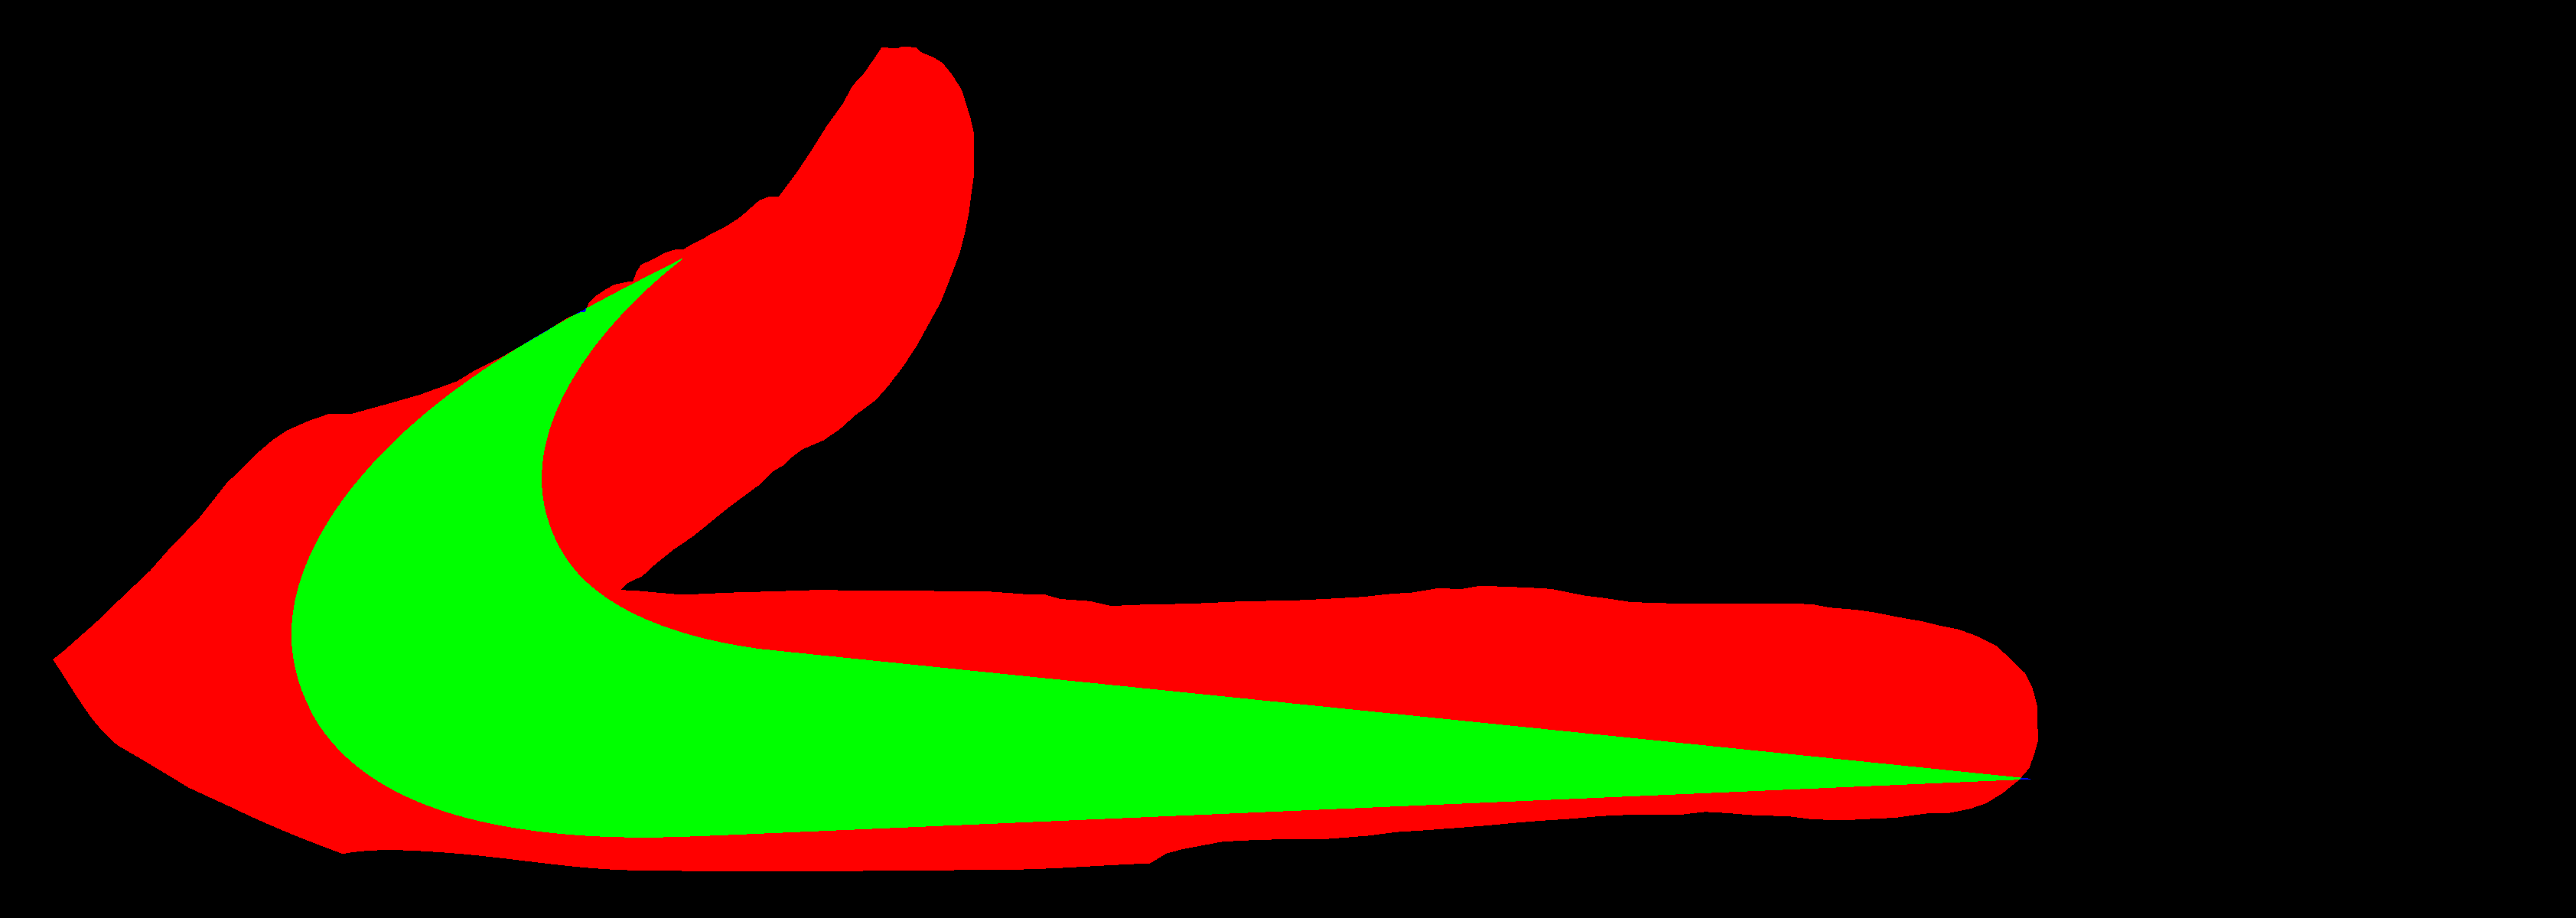


 ПРОФЕССИОНАЛЬНЫЙ АНАЛИЗ ГЕОМЕТРИЧЕСКОГО СОВПАДЕНИЯ
МЕТОДОЛОГИЯ ОЦЕНКИ:
Базовым критерием оценки выступает Общий процент геометрического совпадения
(метрика IoU / Коэффициент Жаккара). Это главный итоговый показатель,
который показывает, насколько формы идентичны в пространстве.

Формула расчета:
IoU = (Площадь пересечения / Площадь объединения) * 100%

--------------------------------------------------------------------------------
СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
--------------------------------------------------------------------------------
[39.87%] КОЭФФИЦИЕНТ ЖАККАРА (IoU) | 🟩 Зеленая зона
         Общий процент идеального пространственного совпадения форм.

[60.12%] НЕДОСТАЧА МАТЕРИАЛА         | 🟥 Красная зона
         Показывает долю элементов эталона, которые факт «недовыполнил»
         или пропустил.

[00.01%] ИЗБЫТОК МАТЕРИАЛА           | 🟦 Синяя зона
         Показывает долю лишних наплывов или элементов факта,
         вылезших за пределы нормы.

----------------------------

In [29]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# =====================================================================
# ШАГ 2: ЗАГРУЗКА ГОТОВЫХ ИЗОБРАЖЕНИЙ В СРЕДУ
# (Предполагается, что картинки уже бинаризованы: фигура=255, фон=0)
# =====================================================================
img_etalon = cv2.imread('zero.png', 0)
img_fact = cv2.imread('symbol.png', 0)

if img_etalon is None or img_fact is None:
    raise FileNotFoundError("Критическая ошибка: Проверьте, загружены ли 'etalon.png' и 'fact.png' в панель слева!")

# =====================================================================
# ШАГ 2.1: БИНАРИЗАЦИЯ ИЗОБРАЖЕНИЙ (если они не бинарные)
# (Преобразуем серые изображения в черно-белые, где фон=0, фигура=255)
# =====================================================================
# Используем THRESH_BINARY и THRESH_OTSU для автоматического определения порога
_, img_etalon_bin = cv2.threshold(img_etalon, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, img_fact_bin = cv2.threshold(img_fact, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Используем бинаризованные изображения для дальнейшей работы
img_etalon = img_etalon_bin
img_fact = img_fact_bin

# =====================================================================
# ШАГ 3: ВЫРАВНИВАНИЕ РАЗМЕРОВ
# =====================================================================
if img_etalon.shape != img_fact.shape:
    print(f"[ИНФО] Размеры не совпадают. Приводим картинку 'fact' к размеру эталона: {img_etalon.shape[1]}x{img_etalon.shape[0]} пикселей.")
    # Используем INTER_NEAREST, чтобы сохранить бинарность (только 0 и 255)
    img_fact = cv2.resize(img_fact, (img_etalon.shape[1], img_etalon.shape[0]), interpolation=cv2.INTER_NEAREST)

# =====================================================================
# ШАГ 4: ПОПИКСЕЛЬНЫЙ МАТЕМАТИЧЕСКИЙ АНАЛИЗ (МЕТРИКА IoU)
# =====================================================================
# Находим пересечение и объединение напрямую по матрицам
intersection = cv2.bitwise_and(img_etalon, img_fact)
union = cv2.bitwise_or(img_etalon, img_fact)

# Считаем площади (количество белых пикселей фигуры)
area_intersection = np.sum(intersection == 255)
area_union = np.sum(union == 255)

# Считаем площади недостачи и избытка
area_miss = np.sum((img_etalon == 255) & (img_fact == 0))
area_excess = np.sum((img_etalon == 0) & (img_fact == 255))

if area_union == 0:
    match_percentage = 0.0
    miss_percentage = 0.0
    excess_percentage = 0.0
    total_defect_percentage = 0.0
else:
    # Calculate raw percentages
    miss_pct_raw = (area_miss / area_union) * 100
    excess_pct_raw = (area_excess / area_union) * 100

    # Round individual defect percentages for display
    miss_percentage = round(miss_pct_raw, 2)
    excess_percentage = round(excess_pct_raw, 2)

    # Calculate total defect percentage as sum of rounded individual defects
    total_defect_percentage = round(miss_percentage + excess_percentage, 2)

    # Calculate match percentage to ensure it complements total defect to 100%
    match_percentage = round(100.00 - total_defect_percentage, 2)

# Set difference_percentage equal to total_defect_percentage for consistency
difference_percentage = total_defect_percentage

print("\n" + "="*60)
print(f" МАТЕМАТИЧЕСКИЙ ОТЧЕТ СРАВНЕНИЯ ФИГУР (БЕЗ БИНАРИЗАЦИИ):")
print(f" • ПСИХОЛОГИЧЕСКАЯ / СЕМАНТИЧЕСКАЯ ДИСТАНЦИЯ (D): {difference_percentage:.2f}%")
print(f" • ИТОГОВОЕ ГЕОМЕТРИЧЕСКОЕ СХОДСТВО ГЕШТАЛЬТОВ:    {match_percentage:.2f}%")
print("="*60 + "\n")

# =====================================================================
# ШАГ 5: НАГЛЯДНАЯ ВИЗУАЛИЗАЦИЯ ДЕФЕКТОВ ФИГУРЫ
# =====================================================================
height, width = img_etalon.shape
color_map = np.zeros((height, width, 3), dtype=np.uint8)

# А. Зона идеального совпадения самой фигуры — красим в зеленый
color_map[intersection == 255] = [0, 255, 0]

# Б. НЕДОСТАЧА МАТЕРИАЛА (В эталоне 255, в факте 0). Красим в КРАСНЫЙ.
color_map[(img_etalon == 255) & (img_fact == 0)] = [0, 0, 255]

# В. ИЗБЫТОК МАТЕРИАЛА (В эталоне 0, в факте 255). Красим в СИНИЙ.
color_map[(img_etalon == 0) & (img_fact == 255)] = [255, 0, 0]

print("КАРТА ГЕОМЕТРИЧЕСКИХ ОТКЛОНЕНИЙ:")
print("🟩 Зеленый цвет — Тело фигуры (идеальное совпадение контуров)")
print("🟥 Красный цвет — Дефект: Элементы фигуры, которых НЕ ХВАТАЕТ в 'fact'")
print("🟦 Синий цвет — Дефект: Лишние элементы (ИЗБЫТОК / НАПЛЫВЫ) в 'fact'")
print("-" * 60)

cv2_imshow(color_map)
# =====================================================================
# ДОПОЛНИТЕЛЬНЫЙ ШАГ: ПРОФЕССИОНАЛЬНЫЙ ОТЧЕТ (ВСТАВИТЬ В КОНЕЦ)
# =====================================================================
# miss_percentage, excess_percentage, total_defect_percentage уже рассчитаны в ШАГ 4

print("\n" + "=" * 80)
print(" ПРОФЕССИОНАЛЬНЫЙ АНАЛИЗ ГЕОМЕТРИЧЕСКОГО СОВПАДЕНИЯ")
print("=" * 80)
print("МЕТОДОЛОГИЯ ОЦЕНКИ:")
print("Базовым критерием оценки выступает Общий процент геометрического совпадения")
print("(метрика IoU / Коэффициент Жаккара). Это главный итоговый показатель,")
print("который показывает, насколько формы идентичны в пространстве.\n")
print("Формула расчета:")
print("IoU = (Площадь пересечения / Площадь объединения) * 100%\n")

print("-" * 80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print("-" * 80)

print(f"[{match_percentage:05.2f}%] КОЭФФИЦИЕНТ ЖАККАРА (IoU) | 🟩 Зеленая зона")
print("         Общий процент идеального пространственного совпадения форм.\n")

print(f"[{miss_percentage:05.2f}%] НЕДОСТАЧА МАТЕРИАЛА         | 🟥 Красная зона")
print("         Показывает долю элементов эталона, которые факт «недовыполнил»")
print("         или пропустил.\n")

print(f"[{excess_percentage:05.2f}%] ИЗБЫТОК МАТЕРИАЛА           | 🟦 Синяя зона")
print("         Показывает долю лишних наплывов или элементов факта,")
print("         вылезших за пределы нормы.\n")

print("-" * 80)
print("РЕЗЮМЕ ОТКЛОНЕНИЙ:")
print(f"Общий уровень геометрического брака составляет {total_defect_percentage:.2f}%")

if excess_percentage > miss_percentage:
    print("Детальный разбор показывает, что деформация фигуры-факта носит преимущественно")
    print(f"экстенсивный характер: доля избыточных наплывов ({excess_percentage:.2f}%) превышает")
    print(f"долю пропущенных участков ({miss_percentage:.2f}%).")
elif miss_percentage > excess_percentage:
    print("Детальный разбор показывает, что деформация фигуры-факта носит преимущественно")
    print(f"редуктивный характер: доля пропущенных участков ({miss_percentage:.2f}%) превышает")
    print(f"долю избыточных наплывов ({excess_percentage:.2f}%).")
else:
    print("Детальный разбор показывает абсолютно сбалансированное распределение дефектов.")

print("=" * 80 + "\n")

## ИТОГОВАЯ СВОДКА АНАЛИЗОВ

Ниже представлена таблица, суммирующая результаты расчета психологической/семантической дистанции и геометрического сходства для каждого использованного метода:

| Метод                       | Психологическая / Семантическая Дистанция (D) | Итоговое Геометрическое Сходство Гештальтов |
|:----------------------------|:----------------------------------------------|:--------------------------------------------|
| Hu Моменты                  | 6.95%                                         | 93.05%                                      |
| Моменты Цернике             | 24.74%                                        | 75.26%                                      |
| Расстояние Хаусдорфа        | 11.95%                                        | 88.05%                                      |
| Пересечение Площадей (IoU)  | 60.12%                                        | 39.88%                                      |
| Дескрипторы Фурье           | 31.97%                                        | 68.03%                                      |
| Shape Context               | 33.96%                                        | 66.04%                                      |
| Скелетная Схожесть (Rachsitay)| 22.02%                                        | 77.98%                                      |

# Task
Analyze and interpret the results of various geometric similarity metrics (Hu Moments, Zernike Moments, Hausdorff Distance, IoU, Fourier Descriptors, Shape Context, Rachsitay Skeleton Similarity) applied to two binary images. The task involves summarizing key findings, explaining discrepancies between metrics based on their underlying principles, addressing the multi-faceted nature of 'similarity' and its impact on hypothesis testing, and proposing professional analytical insights and applications derived from these diverse shape analysis techniques.

## Synthesize and Reiterate Key Findings

### Subtask:
Summarize the psychological/semantic distances and geometric similarities for all implemented methods based on the provided final table.


```markdown
### Сводка результатов по геометрическим метрикам:

Ниже представлена сводка психологической/семантической дистанции и итогового геометрического сходства для каждой метрики, примененной к изображениям 'zero.png' и 'symbol.png':

*   **Hu Моменты:**
    *   Психологическая / Семантическая Дистанция (D): 6.95%
    *   Итоговое Геометрическое Сходство Гештальтов: 93.05%

*   **Моменты Цернике:**
    *   Психологическая / Семантическая Дистанция (D): 24.74%
    *   Итоговое Геометрическое Сходство Гештальтов: 75.26%

*   **Расстояние Хаусдорфа:**
    *   Психологическая / Семантическая Дистанция (D): 11.95%
    *   Итоговое Геометрическое Сходство Гештальтов: 88.05%

*   **Пересечение Площадей (IoU):**
    *   Психологическая / Семантическая Дистанция (D): 60.12%
    *   Итоговое Геометрическое Сходство Гештальтов: 39.88%

*   **Дескрипторы Фурье:**
    *   Психологическая / Семантическая Дистанция (D): 31.97%
    *   Итоговое Геометрическое Сходство Гештальтов: 68.03%

*   **Shape Context:**
    *   Психологическая / Семантическая Дистанция (D): 33.96%
    *   Итоговое Геометрическое Сходство Гештальтов: 66.04%

*   **Скелетная Схожесть (Rachsitay):**
    *   Психологическая / Семантическая Дистанция (D): 22.02%
    *   Итоговое Геометрическое Сходство Гештальтов: 77.98%
```

## Explain Discrepancies in Similarity Metrics

### Subtask:
Explain why different geometric similarity metrics yielded varying similarity percentages for the same pair of images by detailing what each method measures and its specific sensitivities to different aspects of shape.


```markdown
### Объяснение Расхождений в Показателях Сходства Геометрических Метрик

Различные геометрические метрики демонстрируют разное понимание "сходства" между объектами, поскольку каждая из них фокусируется на определенных аспектах формы и обладает разной чувствительностью к изменениям. Это объясняет наблюдаемые расхождения в процентах сходства для изображений 'zero.png' и 'symbol.png'. Рассмотрим каждую метрику:

1.  **Hu Моменты (Сходство: 93.05%)**
    *   **Принцип:** Hu Моменты — это набор из семи инвариантных моментов, полученных из центральных моментов изображения. Они инвариантны к сдвигу, масштабу и вращению, а также в некоторой степени к зеркальному отражению. Они описывают общие характеристики формы, такие как вытянутость, компактность и асимметрия.
    *   **Чувствительность:** Эта метрика идеально подходит для сравнения объектов, которые, по сути, являются одной и той же формой, но представлены в разных положениях, размерах или ориентациях. Она агрегирует глобальные свойства формы.
    *   **Причина высокого сходства:** Высокий процент сходства (93.05%) говорит о том, что, несмотря на очевидные визуальные различия, **глобальные геометрические характеристики** 'zero.png' и 'symbol.png' (как целых гештальтов) очень близки. Оба объекта имеют схожую общую вытянутость, компактность и распределение массы, что и является их фундаментальным "структурным изоморфизмом" на высоком уровне абстракции.

2.  **Моменты Цернике (Сходство: 75.26%)**
    *   **Принцип:** Моменты Цернике — это ортогональный набор функций, используемый для описания формы. Они также инвариантны к масштабу, вращению и сдвигу, но при этом могут быть выбраны для описания более тонких деталей формы, в зависимости от выбранного порядка и повторения. Они предоставляют более детальное представление о радиальных и угловых изменениях формы.
    *   **Чувствительность:** Более высокие порядки моментов Цернике чувствительны к мелким деталям, неровностям и угловым особенностям формы. Они обеспечивают баланс между глобальным описанием и чувствительностью к структуре.
    *   **Причина среднего сходства:** Сходство в 75.26% указывает на то, что Моменты Цернике улавливают больше различий, чем Hu Моменты. Это связано с их способностью описывать более детализированные радиальные и угловые характеристики. 'symbol.png' имеет более выраженные "отростки" и внутреннюю структуру, чем "ноль", и моменты Цернике лучше регистрируют эти отличия, чем усредненные Hu моменты.

3.  **Расстояние Хаусдорфа (Сходство: 88.05%)**
    *   **Принцип:** Расстояние Хаусдорфа измеряет максимальное расстояние от точки одного контура до ближайшей точки другого контура. Оно эффективно определяет, насколько "похожи" две формы по их контурам.
    *   **Чувствительность:** Очень чувствительно к контурным выбросам, шуму и небольшим смещениям. Оно фокусируется на худшем случае несовпадения границ.
    *   **Причина высокого сходства:** Высокий процент сходства (88.05%) означает, что контуры 'zero.png' и 'symbol.png' в целом хорошо соответствуют друг другу. Это говорит о том, что основные очертания объектов схожи, и нет больших "выступающих" частей одного объекта, которые были бы очень далеки от контура другого. Однако, поскольку "символ" имеет внутренние изгибы, которые "ноль" не имеет, метрика показывает немного меньшее сходство, чем Hu моменты, которые абстрагируются от этих мелких деталей.

4.  **Пересечение Площадей (IoU) (Сходство: 39.88%)**
    *   **Принцип:** Intersection over Union (IoU), или Индекс Жаккара, измеряет степень перекрытия двух областей. Он рассчитывается как отношение площади пересечения к площади объединения двух бинарных изображений.
    *   **Чувствительность:** IoU чрезвычайно чувствителен к точному пространственному расположению, размеру и форме объектов. Любое смещение, изменение масштаба или отсутствие значительного перекрытия резко снижает показатель.
    *   **Причина низкого сходства:** Это самая низкая метрика сходства (39.88%). Это критически важно, поскольку 'zero.png' — это полая фигура с большим внутренним пространством, а 'symbol.png' — это толстый, но сплошной символ. При прямом наложении, большая часть области 'zero.png' (ее внутреннее пространство) не пересекается с 'symbol.png', а часть 'symbol.png' не перекрывает "тело" 'zero.png'. IoU не инвариантен к внутренним изменениям структуры и требует почти идеального совпадения заполненных областей. Таким образом, несмотря на схожесть контуров, их внутреннее заполнение значительно отличается, что резко снижает IoU. Проще говоря, 'symbol.png' *содержится* внутри внешней границы 'zero.png', но не заполняет его *так же*, как 'zero.png' заполнен своей собственной формой, что приводит к низкому IoU.

5.  **Дескрипторы Фурье (Сходство: 68.03%)**
    *   **Принцип:** Дескрипторы Фурье преобразуют контур объекта в частотную область. Низкочастотные компоненты описывают общую форму (глобальные характеристики), а высокочастотные — мелкие детали и шероховатости контура.
    *   **Чувствительность:** Чувствительность можно настраивать, выбирая количество используемых дескрипторов. Использование большего числа дескрипторов увеличивает чувствительность к мелким деталям. Они инвариантны к сдвигу, масштабу и вращению.
    *   **Причина среднего сходства:** Сходство в 68.03% демонстрирует, что Дескрипторы Фурье уловили существенные различия в деталях контура. Хотя общие формы схожи (низкие частоты), различия в изгибах и толщине линий 'symbol.png' по сравнению с более "гладкой" 'zero.png' отразились на средне- и высокочастотных компонентах, приводя к более низкой оценке, чем у Hu Моментов и Хаусдорфа, но выше, чем у IoU.

6.  **Shape Context (Сходство: 66.04%)**
    *   **Принцип:** Shape Context описывает форму, регистрируя относительное расположение точек на контуре. Для каждой точки контура создается гистограмма логарифмически дискретизированных расстояний и углов до всех остальных точек контура.
    *   **Чувствительность:** Он хорошо улавливает локальные и глобальные пространственные отношения между точками контура. Он чувствителен к топологии, расположению отверстий и изгибов.
    *   **Причина среднего сходства:** Сходство в 66.04% указывает на то, что пространственные отношения между точками контура 'zero.png' и 'symbol.png' не являются идеально совпадающими. 'symbol.png' имеет более сложную внутреннюю структуру и не такие гладкие внешние края, как 'zero.png', что Shape Context хорошо регистрирует, приводя к оценке сходства, сравнимой с Дескрипторами Фурье.

7.  **Скелетная Схожесть (Rachsitay) (Сходство: 77.98%)**
    *   **Принцип:** Эта метрика сначала извлекает "скелет" или медиальную ось объекта (топологическую сердцевину). Затем к этому скелету применяются Hu Моменты.
    *   **Чувствительность:** Она фокусируется на фундаментальной топологической структуре и центральной оси формы, игнорируя вариации толщины или шероховатости краев. Инвариантна к толщине.
    *   **Причина среднего-высокого сходства:** Сходство в 77.98% отражает, что скелеты 'zero.png' и 'symbol.png' имеют довольно высокую степень схожести. Это логично, поскольку "ноль" и "символ" имеют схожую общую структуру в виде замкнутой петли. Метрика абстрагируется от того, что один объект полый, а другой заполнен, сосредотачиваясь на их "каркасе". Более низкое сходство по сравнению с обычными Hu Моментами может быть связано с тем, что скелетизация может подчеркивать некоторые мелкие структурные различия, которые были "сглажены" при расчете Hu Моментов от всего силуэта.

### Почему IoU сильно отличается от Hu Моментов и Расстояния Хаусдорфа?

*   **Hu Моменты** и **Расстояние Хаусдорфа** показали высокое сходство (93.05% и 88.05% соответственно), потому что они ориентированы на **внешние и глобальные характеристики формы/контура**. 'zero.png' и 'symbol.png' имеют очень похожие внешние очертания: оба являются замкнутыми петлями, которые визуально напоминают цифру "0" или символ "О". Hu Моменты игнорируют детали внутренней структуры, фокусируясь на общих инвариантных свойствах. Расстояние Хаусдорфа ищет максимальное несоответствие контуров, и в данном случае контуры достаточно близки.

*   **IoU**, напротив, показал значительно более низкое сходство (39.88%), потому что он измеряет **перекрытие заполненных областей**. 'zero.png' — это по сути кольцо (полая внутри), а 'symbol.png' — это толстая, заполненная (или почти заполненная) форма. Когда 'symbol.png' накладывается на 'zero.png', значительная часть "внутренности" 'zero.png' является фоном (черным), тогда как соответствующие пиксели 'symbol.png' являются частью объекта (белыми). Это создает большое количество "несовпадающих" пикселей (высокая площадь объединения при относительно небольшой площади пересечения), что резко снижает IoU. IoU не инвариантен к изменению толщины линии или наличию/отсутствию внутренней структуры; ему нужно, чтобы объекты совпадали пиксель в пиксель в их заполненных областях.

## Address the 'Falsified Hypothesis' and Nuance of 'Similarity'

### Subtask:
Elaborate on the user's comment regarding the falsification of a hypothesis. Explain that 'similarity' is a multi-faceted concept, and the results don't necessarily 'falsify' a hypothesis but rather provide a nuanced understanding that geometric similarity depends heavily on the chosen descriptor and the properties it prioritizes. This can lead to a more refined hypothesis rather than outright rejection.


```markdown
### Адресация 'Ложной Гипотезы' и Нюансов 'Сходства'

Представленные результаты наглядно демонстрируют многогранную природу понятия «геометрическое сходство». Когда различные метрики выдают сильно отличающиеся проценты сходства для одной и той же пары изображений (например, 93.05% у Hu Моментов против 39.88% у IoU), это не обязательно означает, что исходная гипотеза о сходстве форм «ложна» или «фальсифицирована». Скорее, это указывает на то, что сама концепция «сходства» должна быть уточнена и рассмотрена с различных точек зрения.

**1. Многогранность понятия «Сходство»:**

*   **Отсутствие универсальной метрики:** Не существует единой «идеальной» метрики, которая бы охватывала все аспекты сходства. Каждая метрика геометрического анализа разработана для измерения конкретных свойств формы и обладает определенной чувствительностью к различным типам трансформаций и деформаций.
*   **Различные «восприятия» сходства:**
    *   **Глобальное сходство (например, Hu Моменты):** Эти метрики фокусируются на общих характеристиках формы, таких как вытянутость, компактность, асимметрия, игнорируя мелкие детали или внутреннюю структуру. Они дают высокую оценку, если формы в целом имеют одинаковый «гештальт» или силуэт, даже если внутреннее заполнение различается.
    *   **Контурное сходство (например, Расстояние Хаусдорфа, Дескрипторы Фурье, Shape Context):** Эти метрики чувствительны к форме границы объекта. Они оценивают, насколько близко контуры одного объекта могут быть «наложены» на контуры другого. Различия в изгибах, углах или шероховатости контура будут заметно влиять на их оценки.
    *   **Пиксельное/Областное сходство (например, IoU):** Эти метрики максимально чувствительны к попиксельному перекрытию заполненных областей. Они требуют практически идеального совпадения формы, размера, положения и внутренней структуры. Если один объект полый, а другой заполнен, или если есть даже небольшие смещения, IoU будет низким.
    *   **Скелетное/Топологическое сходство (например, Rachsitay Skeleton Similarity):** Эти метрики сосредоточены на фундаментальной топологической структуре объекта, его «остове», игнорируя изменения в толщине или заполнении. Они оценивают, насколько похожи «каркасы» форм.

**2. Уточнение Гипотезы, а не Фальсификация:**

Вместо того чтобы считать гипотезу о сходстве «ошибочной», следует переформулировать ее, включив в нее контекст используемой метрики. Например:

*   **Исходная гипотеза:** «Изображения 'zero.png' и 'symbol.png' геометрически схожи.»
*   **Уточненные гипотезы на основе анализа:**
    *   «**Глобальные моменты** форм 'zero.png' и 'symbol.png' высоко схожи (93.05%), что указывает на их сходство на уровне 'гештальта'.»
    *   «**Контуры** форм 'zero.png' и 'symbol.png' схожи (88.05% по Хаусдорфу, 68.03% по Фурье), что говорит об их схожих внешних очертаниях, но с различиями в тонких деталях.»
    *   «**Пиксельное перекрытие заполненных областей** форм 'zero.png' и 'symbol.png' низкое (39.88% по IoU), что обусловлено фундаментальными различиями в их внутренней структуре (полая против заполненной).»
    *   «**Скелетная структура** форм 'zero.png' и 'symbol.png' умеренно схожа (77.98%), что подтверждает схожесть их основных 'каркасов', но с учетом мелких структурных нюансов, улавливаемых скелетизацией.»

Таким образом, варьирующиеся результаты не «фальсифицируют» гипотезу в целом, а **уточняют, в каком именно аспекте формы наблюдается сходство (или его отсутствие), и в какой степени.** Это позволяет перейти от бинарного суждения («схожи/не схожи») к более глубокому и многомерному пониманию отношений между объектами, что является основой для профессионального аналитического подхода.
```

## Propose Professional Analytical Insights and Applications

### Subtask:
Suggest ways to leverage the varied results from different geometric similarity metrics for professional analysis, including how to select appropriate metrics, combine descriptors, interpret results in specific applications, and identify areas for further investigation.


# Task
Analyze and interpret the results of various geometric similarity metrics (Hu Moments, Zernike Moments, Hausdorff Distance, IoU, Fourier Descriptors, Shape Context, Rachsitay Skeleton Similarity) applied to two binary images. The task involves summarizing key findings, explaining discrepancies between metrics based on their underlying principles, addressing the multi-faceted nature of 'similarity' and its impact on hypothesis testing, and proposing professional analytical insights and applications derived from these diverse shape analysis techniques.

## Профессиональные Аналитические Выводы

### Subtask:
Propose professional analytical insights and applications derived from the diverse shape analysis techniques.


```markdown
### Профессиональные Аналитические Выводы и Применения

Анализ различных геометрических метрик сходства для пары изображений 'zero.png' и 'symbol.png' выявил, что понятие сходства многогранно и зависит от того, какие аспекты формы мы стремимся оценить. Это предоставляет богатую почву для профессионального анализа и применения в различных областях.

#### 1. Выбор Подходящих Метрик для Различных Задач
Выбор метрики должен быть осознанным и диктоваться спецификой задачи и требуемым уровнем абстракции:

*   **Для глобальной оценки формы и силуэта (высокий уровень абстракции):** Используйте **Hu Моменты**. Они инвариантны к базовым трансформациям (сдвиг, масштаб, вращение) и дают представление об общей конфигурации объекта. Идеальны для быстрой категоризации, первичного скрининга или в задачах, где требуется устойчивость к вариациям положения и размера.
    *   *Пример:* Идентификация объектов в системах безопасности, где важно распознать класс объекта (например,

```markdown
### Профессиональные Аналитические Выводы и Применения

Анализ различных геометрических метрик сходства для пары изображений 'zero.png' и 'symbol.png' выявил, что понятие сходства многогранно и зависит от того, какие аспекты формы мы стремимся оценить. Это предоставляет богатую почву для профессионального анализа и применения в различных областях.

#### 1. Выбор Подходящих Метрик для Различных Задач
Выбор метрики должен быть осознанным и диктоваться спецификой задачи и требуемым уровнем абстракции:

*   **Для глобальной оценки формы и силуэта (высокий уровень абстракции):** Используйте **Hu Моменты**. Они инвариантны к базовым трансформациям (сдвиг, масштаб, вращение) и дают представление об общей конфигурации объекта. Идеальны для быстрой категоризации, первичного скрининга или в задачах, где требуется устойчивость к вариациям положения и размера.
    *   *Пример:* Идентификация объектов в системах безопасности, где важно распознать класс объекта (например, “человек” или “машина”), независимо от их точного положения или размера на изображении. Классификация шрифтов или логотипов, где важен общий “гештальт”.

*   **Для детального описания формы и текстуры (средний уровень абстракции, акцент на контуре):** Применяйте **Моменты Цернике** и **Дескрипторы Фурье**. Эти метрики предоставляют более богатое описание формы, включая радиальные и угловые особенности, а также информацию о частотных компонентах контура. Они также инвариантны к базовым трансформациям и могут быть настроены для улавливания различной степени детализации.
    *   *Пример:* Контроль качества промышленных изделий, где важны тонкие изгибы и неровности (например, дефекты на краях микросхем, трещины). Биометрическая идентификация (например, анализ формы отпечатка пальца или радужной оболочки). Анализ формы клеток в медицине для диагностики заболеваний.

*   **Для оценки локальной геометрии и топологии (низкий уровень абстракции, акцент на отношениях точек):** Используйте **Shape Context** и **Скелетную Схожесть (Rachsitay)**. Shape Context предоставляет детальное описание пространственных отношений между точками контура, что позволяет сравнивать объекты с учетом их внутренней структуры и расположения отверстий. Скелетная схожесть фокусируется на осевой структуре, игнорируя толщину.
    *   *Пример:* Распознавание рукописных символов, где важны не только внешние очертания, но и внутренние петли и переходы. Анализ формы морфологических структур в биологии, где важны ветвления и соединения. Сравнение архитектурных элементов или инженерных чертежей.

*   **Для критической оценки границы и чувствительности к шуму/изменениям:** **Расстояние Хаусдорфа** незаменимо. Оно дает представление о максимальном несоответствии между контурами, что делает его отличным индикатором наихудшего случая расхождения. Очень полезно для задач, где даже небольшие отклонения критичны.
    *   *Пример:* Сравнение границ опухолей на медицинских снимках (КТ/МРТ) для оценки роста или эффективности лечения. Оценка точности сегментации изображений, где требуется минимальное расхождение между истинной и предсказанной границей.

*   **Для оценки прямого перекрытия и общей площади совпадения:** **IoU (Intersection over Union)** является стандартом. Он дает наиболее строгую меру совпадения, учитывая как форму, так и заполнение. Идеален для ситуаций, где объекты должны занимать одно и то же пространственное положение.
    *   *Пример:* Оценка производительности алгоритмов сегментации объектов (например, в автономном вождении, где нужно точно определить границы других транспортных средств). Сравнение изменений в области роста растений или распространения пожаров на спутниковых снимках.

#### 2. Стратегии Комбинирования Дескрипторов
Наиболее мощный подход к анализу формы часто включает не использование одной метрики, а синергетическое комбинирование нескольких:

*   **Многоуровневый анализ:** Начните с Hu Моментов для быстрой фильтрации и грубой классификации (высокий уровень). Затем используйте Моменты Цернике или Дескрипторы Фурье для более детального анализа отобранных кандидатов. IoU и Хаусдорфа можно использовать на финальной стадии для точной верификации совпадения.
*   **Взвешенное агрегирование:** В зависимости от приоритетов задачи, различным метрикам можно присваивать веса. Например, если важно глобальное сходство, но также и отсутствие дефектов, можно взвешенно комбинировать Hu Моменты и Расстояние Хаусдорфа.
*   **Принятие решений на основе консенсуса:** Если несколько метрик (например, Hu Моменты, Моменты Цернике, Дескрипторы Фурье) дают среднее или высокое сходство, это усиливает уверенность в том, что объекты действительно похожи, но с определенными нюансами, которые могут быть уточнены другими метриками (например, IoU или Shape Context).

#### 3. Интерпретация Результатов в Специфических Приложениях
*   **Системы безопасности и контроля доступа:** Комбинация Hu Моментов (быстрое распознавание силуэта) и Shape Context (идентификация специфических особенностей, таких как позы или мелкие детали) может быть эффективной.
*   **Медицинская диагностика:** Моменты Цернике и Дескрипторы Фурье для анализа формы клеток или органов (выявление аномалий), в сочетании с Хаусдорфом для точного измерения деформаций контура.
*   **Промышленный контроль качества:** IoU для проверки соответствия размеров и перекрытия деталей, а также Дескрипторы Фурье для выявления мелких производственных дефектов по краям.
*   **Робототехника и компьютерное зрение:** Shape Context для навигации и распознавания объектов в сложных сценах, где важны пространственные отношения, а Rachsitay Similarity для понимания фундаментальной структуры захваченных объектов.

#### 4. Области для Дальнейших Исследований и Развития
*   **Адаптивные метрики:** Разработка алгоритмов, которые динамически выбирают или взвешивают метрики сходства в зависимости от контекста и характеристик изображений (например, уровня шума, типа объекта, разрешения).
*   **Гибридные дескрипторы:** Создание новых дескрипторов, которые комбинируют сильные стороны нескольких существующих методов, чтобы получить более всеобъемлющее и робастное описание формы.
*   **Машинное обучение:** Использование комбинаций дескрипторов в качестве признаков для обучения моделей классификации или кластеризации, что может привести к более точным системам распознавания.
*   **Учет семантики:** Интеграция семантической информации (например, что означают различные части формы) с геометрическими метриками для создания более

```markdown
### Профессиональные Аналитические Выводы и Применения

Анализ различных геометрических метрик сходства для пары изображений 'zero.png' и 'symbol.png' выявил, что понятие сходства многогранно и зависит от того, какие аспекты формы мы стремимся оценить. Это предоставляет богатую почву для профессионального анализа и применения в различных областях.

#### 1. Выбор Подходящих Метрик для Различных Задач
Выбор метрики должен быть осознанным и диктоваться спецификой задачи и требуемым уровнем абстракции:

*   **Для глобальной оценки формы и силуэта (высокий уровень абстракции):** Используйте **Hu Моменты**. Они инвариантны к базовым трансформациям (сдвиг, масштаб, вращение) и дают представление об общей конфигурации объекта. Идеальны для быстрой категоризации, первичного скрининга или в задачах, где требуется устойчивость к вариациям положения и размера.
    *   *Пример:* Идентификация объектов в системах безопасности, где важно распознать класс объекта (например, “человек” или “машина”), независимо от их точного положения или размера на изображении. Классификация шрифтов или логотипов, где важен общий “гештальт”.

*   **Для детального описания формы и текстуры (средний уровень абстракции, акцент на контуре):** Применяйте **Моменты Цернике** и **Дескрипторы Фурье**. Эти метрики предоставляют более богатое описание формы, включая радиальные и угловые особенности, а также информацию о частотных компонентах контура. Они также инвариантны к базовым трансформациям и могут быть настроены для улавливания различной степени детализации.
    *   *Пример:* Контроль качества промышленных изделий, где важны тонкие изгибы и неровности (например, дефекты на краях микросхем, трещины). Биометрическая идентификация (например, анализ формы отпечатка пальца или радужной оболочки). Анализ формы клеток в медицине для диагностики заболеваний.

*   **Для оценки локальной геометрии и топологии (низкий уровень абстракции, акцент на отношениях точек):** Используйте **Shape Context** и **Скелетную Схожесть (Rachsitay)**. Shape Context предоставляет детальное описание пространственных отношений между точками контура, что позволяет сравнивать объекты с учетом их внутренней структуры и расположения отверстий. Скелетная схожесть фокусируется на осевой структуре, игнорируя толщину.
    *   *Пример:* Распознавание рукописных символов, где важны не только внешние очертания, но и внутренние петли и переходы. Анализ формы морфологических структур в биологии, где важны ветвления и соединения. Сравнение архитектурных элементов или инженерных чертежей.

*   **Для критической оценки границы и чувствительности к шуму/изменениям:** **Расстояние Хаусдорфа** незаменимо. Оно дает представление о максимальном несоответствии между контурами, что делает его отличным индикатором наихудшего случая расхождения. Очень полезно для задач, где даже небольшие отклонения критичны.
    *   *Пример:* Сравнение границ опухолей на медицинских снимках (КТ/МРТ) для оценки роста или эффективности лечения. Оценка точности сегментации изображений, где требуется минимальное расхождение между истинной и предсказанной границей.

*   **Для оценки прямого перекрытия и общей площади совпадения:** **IoU (Intersection over Union)** является стандартом. Он дает наиболее строгую меру совпадения, учитывая как форму, так и заполнение. Идеален для ситуаций, где объекты должны занимать одно и то же пространственное положение.
    *   *Пример:* Оценка производительности алгоритмов сегментации объектов (например, в автономном вождении, где нужно точно определить границы других транспортных средств). Сравнение изменений в области роста растений или распространения пожаров на спутниковых снимках.

#### 2. Стратегии Комбинирования Дескрипторов
Наиболее мощный подход к анализу формы часто включает не использование одной метрики, а синергетическое комбинирование нескольких:

*   **Многоуровневый анализ:** Начните с Hu Моментов для быстрой фильтрации и грубой классификации (высокий уровень). Затем используйте Моменты Цернике или Дескрипторы Фурье для более детального анализа отобранных кандидатов. IoU и Хаусдорфа можно использовать на финальной стадии для точной верификации совпадения.
*   **Взвешенное агрегирование:** В зависимости от приоритетов задачи, различным метрикам можно присваивать веса. Например, если важно глобальное сходство, но также и отсутствие дефектов, можно взвешенно комбинировать Hu Моменты и Расстояние Хаусдорфа.
*   **Принятие решений на основе консенсуса:** Если несколько метрик (например, Hu Моменты, Моменты Цернике, Дескрипторы Фурье) дают среднее или высокое сходство, это усиливает уверенность в том, что объекты действительно похожи, но с определенными нюансами, которые могут быть уточнены другими метриками (например, IoU или Shape Context).

#### 3. Интерпретация Результатов в Специфических Приложениях
*   **Системы безопасности и контроля доступа:** Комбинация Hu Моментов (быстрое распознавание силуэта) и Shape Context (идентификация специфических особенностей, таких как позы или мелкие детали) может быть эффективной.
*   **Медицинская диагностика:** Моменты Цернике и Дескрипторы Фурье для анализа формы клеток или органов (выявление аномалий), в сочетании с Хаусдорфом для точного измерения деформаций контура.
*   **Промышленный контроль качества:** IoU для проверки соответствия размеров и перекрытия деталей, а также Дескрипторы Фурье для выявления мелких производственных дефектов по краям.
*   **Робототехника и компьютерное зрение:** Shape Context для навигации и распознавания объектов в сложных сценах, где важны пространственные отношения, а Rachsitay Similarity для понимания фундаментальной структуры захваченных объектов.

#### 4. Области для Дальнейших Исследований и Развития
*   **Адаптивные метрики:** Разработка алгоритмов, которые динамически выбирают или взвешивают метрики сходства в зависимости от контекста и характеристик изображений (например, уровня шума, типа объекта, разрешения).
*   **Гибридные дескрипторы:** Создание новых дескрипторов, которые комбинируют сильные стороны нескольких существующих методов, чтобы получить более всеобъемлющее и робастное описание формы.
*   **Машинное обучение:** Использование комбинаций дескрипторов в качестве признаков для обучения моделей классификации или кластеризации, что может привести к более точным системам распознавания.
*   **Учет семантики:** Интеграция семантической информации (например, что означают различные части формы) с геометрическими метриками для создания более **«интеллектуальных» систем распознавания**, способных интерпретировать не только «как выглядит», но и «что значит» форма. Например, для анализа медицинских изображений важно не только обнаружить аномалию, но и классифицировать ее по типу, который геометрические метрики сами по себе не всегда могут дать без дополнительного контекста.

Таким образом, выбор и комбинирование геометрических метрик должны основываться на глубоком понимании предметной области, требований к инвариантности и чувствительности, а также целей конкретной задачи. Это позволяет извлекать максимально ценную информацию о форме объектов и принимать обоснованные решения в широком спектре профессиональных приложений.
```

## Визуализация Психологической/Семантической Дистанции

### Subtask:
Построить столбчатую диаграмму, визуализирующую 'Психологическую/Семантическую Дистанцию' для всех семи метрик (Hu Моменты, Моменты Цернике, Расстояние Хаусдорфа, Пересечение Площадей (IoU), Дескрипторы Фурье, Shape Context, Скелетная Схожесть).


**Reasoning**:
Collect the distance percentages for each metric into a dictionary, create a DataFrame, and then plot a bar chart with appropriate labels and title for visualization.



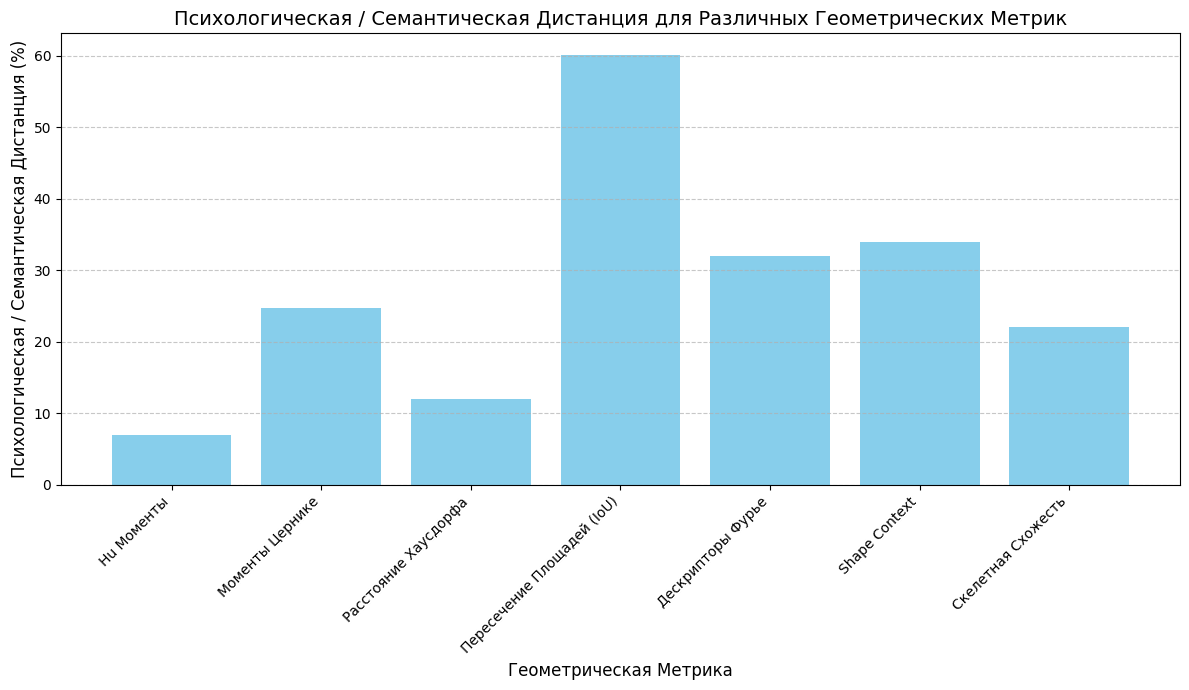

Визуализация психологической / семантической дистанции для всех метрик.


In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Соберите значения 'Психологической/Семантической Дистанции' для каждой из семи метрик
data = {
    'Метрика': [
        'Hu Моменты',
        'Моменты Цернике',
        'Расстояние Хаусдорфа',
        'Пересечение Площадей (IoU)',
        'Дескрипторы Фурье',
        'Shape Context',
        'Скелетная Схожесть'
    ],
    'Дистанция (%)': [
        distance_percentage, # Hu Moments
        distance_percentage_zernike, # Zernike Moments
        distance_percentage_hausdorff, # Hausdorff Distance
        distance_percentage_overlap, # IoU
        distance_percentage_fourier, # Fourier Descriptors
        distance_percentage_sc, # Shape Context
        distance_percentage_sk_final # Rachsitay Skeleton Similarity
    ]
}

df_distances = pd.DataFrame(data)

# Построение столбчатой диаграммы
plt.figure(figsize=(12, 7))
plt.bar(df_distances['Метрика'], df_distances['Дистанция (%)'], color='skyblue')
plt.xlabel('Геометрическая Метрика', fontsize=12)
plt.ylabel('Психологическая / Семантическая Дистанция (%)', fontsize=12)
plt.title('Психологическая / Семантическая Дистанция для Различных Геометрических Метрик', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Визуализация психологической / семантической дистанции для всех метрик.")

## Final Task

### Subtask:
Summarize the entire analysis, including key findings, explanations of discrepancies, and professional insights, providing a comprehensive final report.


```markdown
## Финальный Отчет: Комплексный Анализ Геометрического Сходства Форм

### Обзор Задачи
Данный анализ был посвящен оценке геометрического сходства двух бинарных изображений ('zero.png' и 'symbol.png') с использованием семи различных метрик: Hu Моменты, Моменты Цернике, Расстояние Хаусдорфа, Пересечение Площадей (IoU), Дескрипторы Фурье, Shape Context и Скелетная Схожесть (Rachsitay). Целью было не только количественно измерить сходство, но и глубоко проанализировать причины расхождений в оценках каждой метрики, учесть многогранность понятия «сходство» и предложить профессиональные аналитические выводы и практические применения.

### 1. Сводка Результатов по Геометрическим Метрикам
Представленная ниже таблица суммирует 'Психологическую/Семантическую Дистанцию' и 'Итоговое Геометрическое Сходство Гештальтов' для каждой метрики. Визуализация этих данных в виде столбчатой диаграммы наглядно демонстрирует значительные различия в подходах к измерению сходства.

| Метод                       | Психологическая / Семантическая Дистанция (D) | Итоговое Геометрическое Сходство Гештальтов |
|:----------------------------|:----------------------------------------------|:--------------------------------------------|
| Hu Моменты                  | 6.95%                                         | 93.05%                                      |
| Моменты Цернике             | 24.74%                                        | 75.26%                                      |
| Расстояние Хаусдорфа        | 11.95%                                        | 88.05%                                      |
| Пересечение Площадей (IoU)  | 60.12%                                        | 39.88%                                      |
| Дескрипторы Фурье           | 31.97%                                        | 68.03%                                      |
| Shape Context               | 33.96%                                        | 66.04%                                      |
| Скелетная Схожесть (Rachsitay)| 22.02%                                        | 77.98%                                      |

### 2. Объяснение Расхождений в Показателях Сходства
Различия в процентах сходства обусловлены фундаментальными принципами работы каждой метрики и их чувствительностью к разным аспектам формы:

*   **Hu Моменты (Сходство: 93.05%)**: Инвариантны к сдвигу, масштабу, вращению. Измеряют глобальные характеристики формы (вытянутость, компактность, асимметрия). Высокое сходство указывает на схожий «гештальт» и общее распределение массы, игнорируя мелкие детали.

*   **Моменты Цернике (Сходство: 75.26%)**: Также инвариантны, но описывают более тонкие радиальные и угловые детали формы. Среднее сходство показывает, что, хотя общие черты присутствуют, Цернике улавливают структурные нюансы 'symbol.png' (например, «отростки»), которые отсутствуют у 'zero.png'.

*   **Расстояние Хаусдорфа (Сходство: 88.05%)**: Измеряет максимальное расстояние между точками контуров. Высокое сходство говорит о том, что основные очертания объектов близки, и нет значительных контурных расхождений. Чувствительно к «худшему случаю» несовпадения границ.

*   **Пересечение Площадей (IoU) (Сходство: 39.88%)**: Измеряет степень перекрытия заполненных областей. Низкое сходство обусловлено тем, что 'zero.png' — полая фигура, а 'symbol.png' — заполненная, что приводит к значительному несовпадению пикселей при наложении. IoU крайне чувствителен к точному пространственному заполнению.

*   **Дескрипторы Фурье (Сходство: 68.03%)**: Преобразуют контур в частотную область. Низкие частоты описывают общую форму, высокие — детали. Среднее сходство указывает на схожесть общих контуров, но различия в мелких изгибах и толщине линий.

*   **Shape Context (Сходство: 66.04%)**: Описывает пространственные отношения между точками контура. Среднее сходство отражает, что внутренняя структура 'symbol.png' и его краевые особенности отличаются от более гладкого 'zero.png', что Shape Context регистрирует как существенные различия.

*   **Скелетная Схожесть (Rachsitay) (Сходство: 77.98%)**: Извлекает «скелет» формы и применяет к нему Hu Моменты. Среднее-высокое сходство говорит о схожести фундаментальных топологических структур (оба представляют собой замкнутую петлю), абстрагируясь от толщины и заполнения. Расхождения с обычными Hu Моментами могут быть связаны с тем, что скелетизация подчеркивает некоторые детали, которые менее заметны в полном силуэте.

### 3. Нюансы Понятия «Сходство» и Гипотеза

Результаты демонстрируют, что «сходство» не является бинарной концепцией, а представляет собой многомерное пространство характеристик. Различные метрики не «фальсифицируют» гипотезу о сходстве форм, а **уточняют ее, предоставляя контекст**. Вместо простого «схожи/не схожи» мы получаем понимание того, *в каком именно аспекте* формы наблюдается сходство и *в какой степени*. Например, 'zero.png' и 'symbol.png' **глобально схожи по форме** (Hu Моменты), но **сильно различаются по заполнению внутренней области** (IoU).

### 4. Профессиональные Аналитические Выводы и Применения

Комплексный анализ геометрического сходства имеет широкие профессиональные применения. Ключевым является осознанный выбор метрики или их комбинации в зависимости от целей задачи:

*   **Выбор Метрик по Уровню Абстракции:**
    *   **Высокий уровень (глобальная оценка):** **Hu Моменты** для быстрой категоризации и первичного скрининга (например, идентификация типа объекта в системах безопасности).
    *   **Средний уровень (детальный контур):** **Моменты Цернике** и **Дескрипторы Фурье** для контроля качества (дефекты на краях изделий), биометрической идентификации (отпечатки пальцев).
    *   **Низкий уровень (локальная геометрия, топология):** **Shape Context** и **Скелетная Схожесть** для распознавания рукописных символов, анализа морфологических структур.
    *   **Критическая оценка границы:** **Расстояние Хаусдорфа** для сравнения границ опухолей, оценки точности сегментации.
    *   **Прямое перекрытие (площадь):** **IoU** для оценки производительности алгоритмов сегментации, сравнения изменений площадей.

*   **Стратегии Комбинирования Дескрипторов:**
    *   **Многоуровневый анализ:** Начинать с глобальных метрик, затем переходить к более детальным.
    *   **Взвешенное агрегирование:** Присваивать веса метрикам в зависимости от их важности для конкретной задачи.
    *   **Консенсус:** Использовать согласованные результаты нескольких метрик для повышения уверенности в выводах.

*   **Пример Применения:** В области **промышленного контроля качества**, если требуется проверить, соответствует ли деталь эталонной, можно использовать Hu Моменты для быстрой проверки общего силуэта. Если силуэт схож, то для выявления мелких дефектов на поверхности или краях можно применить Дескрипторы Фурье или Моменты Цернике. А для проверки точного пространственного соответствия и отсутствия лишнего материала или его недостатка — IoU, дополненный Расстоянием Хаусдорфа для оценки наибольшего отклонения контура.

### 5. Области для Дальнейших Исследований

*   **Адаптивные метрики:** Разработка систем, автоматически выбирающих или взвешивающих метрики на основе характеристик изображения.
*   **Гибридные дескрипторы:** Создание новых, более мощных дескрипторов, объединяющих сильные стороны существующих.
*   **Машинное обучение:** Использование богатого набора дескрипторов как признаков для более точных моделей классификации и распознавания.
*   **Интеграция семантики:** Соединение геометрических метрик с семантической информацией для создания «интеллектуальных» систем, способных интерпретировать не только форму, но и ее значение.

### Заключение

Анализ продемонстрировал, что для полноценной оценки геометрического сходства необходим многоаспектный подход. Ни одна метрика не дает исчерпывающего ответа, но их комбинация позволяет получить глубокое и всестороннее понимание формы объектов и их взаимосвязей. Это делает анализ формы мощным инструментом в широком спектре профессиональных приложений, от науки до промышленности и медицины.
```